# State Space Models with `dynestyx` and `numpyro_forecast`

In this notebook we write a
[`dynestyx`](https://github.com/BasisResearch/dynestyx) state space
model as a `numpyro_forecast` model. We then fit it, forecast with it
and backtest it with the drivers of the package, without changing them.

`dynestyx` is a probabilistic programming library for dynamical systems
built on NumPyro. Its central object is a `DynamicalModel`, which
bundles an initial condition, a state evolution and an observation
model. Its primitive, `dsx.sample`, is interpreted by effect handlers. A
`Filter` or a `Smoother` integrates the latent path out with a filtering
algorithm (exactly with the Kalman filter for linear-Gaussian models,
approximately with the ensemble, extended and unscented Kalman filters
and with particle filters) and adds the marginal log likelihood, or its
estimate, to the NumPyro trace. A `LatentPathBuilder` samples the path
explicitly. A `Simulator` rolls the model forward in time.

`numpyro_forecast` is a forecasting workflow layer. A model is a plain
function `(covariates, data=None)` built from model building blocks that
register the `"obs"` and `"forecast"` sites. The drivers
([`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html),
[`predict_in_sample`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.predict_in_sample.html),
[`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html),
[`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html)
and the metrics) read those sites by name.

The two libraries compose at the trace level. We connect them with one
new model building block, `state_space_series`. Its `conditioner`
argument is the `dynestyx` handler that interprets `dsx.sample` over the
observed window. The choice between integrating the latent path out (a
`Smoother`) and sampling it explicitly (a `LatentPathBuilder`) is
therefore a change of one argument.

We proceed as follows:

1.  **Prepare Notebook.** We load the libraries and set the
    configuration.
2.  **The Building Block.** We define `state_space_series` and explain
    its contract.
3.  **Local Level Model.** We fit the same model three times: in the
    direct form of the package, with `dynestyx` sampling the path
    explicitly, and with `dynestyx` integrating it out with a Kalman
    smoother. We compare posteriors, sampler efficiency, forecasts,
    in-sample fits and the reconstructed latent level.
4.  **Seasonal Regression Model.** We add a seasonal regression through
    the covariates, fit it with SVI and run the expanding-window
    backtest of the package on the `dynestyx` model, in and out of
    sample. This is the evaluation direction that the [design
    document](https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/dev/dynestyx_integration_design.md)
    of this integration proposes.
5.  **Conclusion.** We summarize the findings, the limitations and our
    recommendations.

## Prepare Notebook

We load the necessary libraries and set the notebook’s configuration.

In [1]:
import time
from collections.abc import Callable, Sequence
from contextlib import ExitStack
from functools import partial
from typing import Any, NamedTuple

import arviz as az
import dynestyx as dsx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import xarray as xr
from dynestyx import Discretizer, DynamicalModel, Filter, LatentPathBuilder, Simulator, Smoother
from dynestyx.inference.configs.simulator import SimulatorConfig
from dynestyx.inference.configs.smoother import KFSmootherConfig
from dynestyx.inference.filters import KFConfig
from jax import random
from jaxtyping import Float
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import LocScaleReparam
from numpyro.infer.util import log_density
from numpyro.optim import Adam

from numpyro_forecast import (
    Horizon,
    backtest,
    draw_posterior,
    eval_coverage,
    eval_crps,
    eval_mae,
    eval_rmse,
    forecast,
    innovations,
    predict,
    predict_in_sample,
    predictions_to_datatree,
    results_to_dataframe,
    to_datatree,
)
from numpyro_forecast.features import fourier_features
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

print(f"dynestyx {dsx.__version__}, numpyro {numpyro.__version__}, jax {jax.__version__}")

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

dynestyx 0.6.0, numpyro 0.22.0, jax 0.11.2

## The Building Block

The block below is the whole integration. Its docstring states the
contract. It takes the current call’s
[`Horizon`](https://juanitorduz.github.io/numpyro_forecast/reference/models.Horizon.html),
a site name, the observed window `y`, a `dynestyx` `DynamicalModel` and
a **conditioner**. The conditioner is the stack of `dynestyx` handlers
that interpret `dsx.sample` over the observed window. It takes one of
three forms:

- **`Filter` or `Smoother`**: they compute the marginal log likelihood
  $\log p(y_{1:T} \mid \theta)$ of the window and register it as a
  NumPyro factor. The joint density that NUTS or SVI sees is then
  $p(\theta) \, p(y_{1:T} \mid \theta)$, with the latent path integrated
  out. The smoother also provides the smoothing distribution
  $p(x_t \mid y_{1:T}, \theta)$ of every in-window state, which the
  filter does not. It computes it with a backward pass after the forward
  filter, so a full smoother evaluation costs more than a filter
  evaluation. The marginal log likelihood comes from the forward pass
  alone, and the smoothed states are deterministic sites that NumPyro
  recomputes once per MCMC transition, not once per leapfrog step. The
  compiled gradient of the log density therefore costs the same under
  both handlers, because JAX drops the backward pass from it. We measure
  both costs in the Model Diagnostics section. This is a property of the
  current implementation, not a guarantee for every backend or model.
- **`LatentPathBuilder`**: it creates one sample site for the whole path
  and registers the joint density of states and observations as a
  factor. The sampler explores the path explicitly, as it does with the
  package’s own
  [`innovations`](https://juanitorduz.github.io/numpyro_forecast/reference/models.innovations.html).
  The difference is that `dynestyx` builds the path, so discretized
  continuous-time dynamics and observation models with missing values
  are available.
- **`Discretizer`**: it can follow either of the above, as the second
  element of a sequence, and turns a continuous-time model into the
  discrete transition the conditioning handler consumes. We stay with
  discrete-time models here. The [design
  document](https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/dev/dynestyx_integration_design.md)
  records the continuous-time recipe and its caveats.

The block has three modes, and `h.data` selects them. The observations
themselves come from the `y` argument, which the model slices from
`covariates` (the series doubles as a covariate, the same contract as
[`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html)).
This is what lets a model call without data still reach the observed
window.

1.  **Training** (`data` present, no horizon): the block runs
    `dsx.sample` under the conditioner. The factor (and the path site,
    for the builder) enters the trace.
2.  **Forecasting** (`covariates` longer than `data`): the block nests
    the conditioner inside a `Simulator`. `dynestyx` interprets this as
    a posterior rollout that starts from the conditioned distribution of
    the state at the last observed step (the smoothing distribution, the
    filtering distribution or the sampled path, which coincide there).
    The block registers the horizon draws as the `"forecast"` site.
3.  **In-sample predictive** (`data=None`): the block draws the
    in-window states from the conditioner’s posterior over the path (the
    smoothing distribution, or the explicit path), samples one
    observation per step from the observation model and registers them
    as the `"obs"` site. `data=None` is a mode switch, not an absence of
    data. The in-sample predictive is a smoothing task, which is why a
    `Filter` conditioner raises in this mode.

The block owns the likelihood, so it also owns the two sites, like
[`predict`](https://juanitorduz.github.io/numpyro_forecast/reference/models.predict.html).
It returns a `StateSpaceResult` with the state draws of the current
mode, `x_future` over the horizon and `x_in_sample` over the window, so
that a model can register its latent level.

Two details of the implementation matter for correctness:

- **Time grids.** The `Horizon` counts the steps and the `times`
  argument places them. The block slices the observation times from
  `times` and takes the last `future` entries as the forecast times (any
  strictly increasing grid, the step index by default). The handlers
  differ in what they accept. A `Filter` rollout splits the prediction
  grid into segments on the host, so its grid must be a NumPy constant.
  A `LatentPathBuilder` indexes the grid inside a `lax.scan`, so its
  grid must be a jax array (a NumPy grid fails in the eager model call
  that NUTS makes at initialization). A `Smoother` rollout starts from
  one final anchor and accepts either. The block passes NumPy grids to a
  `Filter` or `Smoother` and jax grids to a `LatentPathBuilder`. The
  drivers run the model under `jax.jit`, so a grid derived from a traced
  covariate column would break the `Filter` case.
- **The anchor.** The prediction grid starts at the last observed step,
  `t_obs - 1`, and the block drops the first returned row. The
  simulator’s first predicted state is the conditioned draw at
  `predict_times[0]` without a transition, so this anchor gives exactly
  one transition per horizon step. A grid that starts at `t_obs` would
  report the state of step `t_obs - 1` as the forecast for `t_obs`.

Finally, create the handlers once, outside the model. They are
`dynestyx` objects with state of their own, and the builder caches the
observation layout it needs to run under `jit`.

In [2]:
StateSpaceHandler = Filter | Smoother | LatentPathBuilder | Discretizer
"""A dynestyx handler that interprets ``dsx.sample`` over the observed window."""

_CONDITIONING_HANDLERS = (Filter, Smoother, LatentPathBuilder)


class StateSpaceResult(NamedTuple):
    """Draws produced by `state_space_series` (size-0 time axes when not applicable).

    Each field is filled in the mode that produces it and has a size-0 time axis
    otherwise: the ``future`` fields while forecasting, the ``in_sample`` fields
    when the model is called without data, none while training. The shapes carry
    no batch dims (panels are not supported).

    Attributes
    ----------
    y_future
        Observation draws over the horizon, shape ``(future, obs)``; also
        registered as the ``"forecast"`` site.
    x_future
        Latent state draws over the horizon, shape ``(future, state)``.
    y_in_sample
        One draw of the in-sample predictive, shape ``(t_obs, obs)``; also
        registered as the ``"obs"`` site.
    x_in_sample
        The in-window state draw behind ``y_in_sample``, shape ``(t_obs, state)``:
        the conditioner's posterior over the path (the smoothing distribution, or
        the explicit path), one draw per model call.
    """

    y_future: Float[Array, " future obs"]
    x_future: Float[Array, " future state"]
    y_in_sample: Float[Array, " time obs"]
    x_in_sample: Float[Array, " time state"]


def _handler_stack(
    conditioner: StateSpaceHandler | Sequence[StateSpaceHandler],
) -> tuple[StateSpaceHandler, ...]:
    """Normalize ``conditioner`` to the tuple of handlers entered outermost first."""
    stack = tuple(conditioner) if isinstance(conditioner, Sequence) else (conditioner,)
    conditioning = [i for i, h in enumerate(stack) if isinstance(h, _CONDITIONING_HANDLERS)]
    if len(conditioning) != 1:
        msg = (
            "conditioner needs exactly one Filter, Smoother or LatentPathBuilder "
            f"(optionally followed by a Discretizer), got {[type(h).__name__ for h in stack]}"
        )
        raise ValueError(msg)
    if conditioning[0] != 0:
        msg = (
            "the Filter, Smoother or LatentPathBuilder must come first (outermost) in conditioner"
        )
        raise ValueError(msg)
    return stack


def _time_grid(times: np.ndarray | None, h: Horizon) -> np.ndarray:
    """Full-horizon float times: ``times[:duration]``, or ``0, 1, ..., duration - 1``."""
    if times is None:
        return np.arange(h.duration, dtype=np.float32)
    grid = np.asarray(times, dtype=np.float32)
    if grid.ndim != 1 or grid.shape[0] < h.duration:
        msg = f"times must be a 1-D array with at least duration={h.duration} entries, got {grid.shape}"
        raise ValueError(msg)
    grid = grid[: h.duration]
    if np.any(np.diff(grid) <= 0):
        msg = "times must be strictly increasing"
        raise ValueError(msg)
    return grid


def _in_sample_states(
    name: str, conditioner: StateSpaceHandler, result: Any
) -> Float[Array, " time state"]:
    """One draw of every in-window state from the conditioner's posterior over the path."""
    if isinstance(conditioner, LatentPathBuilder):
        return result.state_path
    if isinstance(conditioner, Smoother):
        dists = result.dists
        if not dists or not isinstance(dists[0], dist.MultivariateNormal):
            msg = (
                "the in-sample predictive needs a Gaussian smoother (per-time MultivariateNormal)"
            )
            raise TypeError(msg)
        mean = jnp.stack([d.mean for d in dists])
        cov = jnp.stack([d.covariance_matrix for d in dists])
        state_dist = dist.MultivariateNormal(mean, covariance_matrix=cov).to_event(1)
        return numpyro.sample(f"{name}_smoothed_states", state_dist)
    msg = (
        "the in-sample predictive (a model call with data=None, as made by predict_in_sample "
        "and to_datatree) needs a Smoother or a LatentPathBuilder conditioner; a Filter only "
        "carries the filtering distribution p(x_t | y_1:t)."
    )
    raise ValueError(msg)


def state_space_series(
    h: Horizon,
    name: str,
    y: Float[Array, " time obs"],
    dynamics: DynamicalModel,
    *,
    conditioner: StateSpaceHandler | Sequence[StateSpaceHandler],
    controls: Float[Array, " duration control"] | None = None,
    times: np.ndarray | None = None,
    simulator_config: SimulatorConfig | None = None,
) -> StateSpaceResult:
    """Condition a dynestyx model on the observed window and predict with it.

    The conditioner is the ``dynestyx`` handler stack that interprets
    ``dsx.sample`` over the observed window, entered outermost first: a
    ``Filter`` or a ``Smoother`` adds the marginal log likelihood of the window as
    a NumPyro factor (the latent path is integrated out), a ``LatentPathBuilder``
    samples the path explicitly, and an optional ``Discretizer`` after it turns a
    continuous-time model into the discrete transition the others consume. The
    block adds the horizon bookkeeping on top and registers the two sites the
    package drivers read. While forecasting it nests the stack inside a
    ``Simulator``, whose posterior rollout starts from the conditioned
    distribution of the state at the last observed step, and registers the
    horizon draws as ``"forecast"``.
    When the model is called without data it draws the in-window states from the
    conditioner's posterior over the path (the smoothing distribution, or the
    explicit path), samples one observation per step from the observation
    model, and registers them as ``"obs"``: the in-sample predictive that
    ``predict_in_sample`` and ``to_datatree`` read. The guide never sees the
    rollout because fitting happens with ``h.future == 0``.

    Parameters
    ----------
    h
        The horizon for the current model call. ``h.data`` selects the mode
        (training when present, in-sample predictive when ``None``); the
        observations themselves come from ``y``.
    name
        Prefix of the ``dynestyx`` sites.
    y
        The observed window, shape ``(t_obs, obs)`` with time at axis ``-2``,
        sliced from ``covariates`` by the caller (the contract of ``ssoe``, so
        that model calls without data still reach the observations).
    dynamics
        The ``dynestyx`` model; its observation dimension must match ``y``.
    conditioner
        ``Filter(filter_config=...)``, ``Smoother(smoother_config=...)`` or
        ``LatentPathBuilder(...)``, alone or as the first element of a sequence
        followed by a ``Discretizer(...)``. Create the handlers once outside the
        model and reuse them: the builder caches the observation layout it
        needs under ``jit``. A ``Filter`` cannot serve the in-sample predictive.
    controls
        Exogenous inputs over the full horizon, shape ``(duration, control)``,
        forwarded as ``ctrl_values`` on the full time grid.
    times
        Observation and forecast times over the full horizon, at least
        ``duration`` strictly increasing entries, a host-side NumPy array;
        ``None`` uses the step index. The last ``future`` entries are the
        forecast times. Irregular spacing matters for continuous-time dynamics
        and for time-varying parameters.
    simulator_config
        Forwarded to ``Simulator`` (solver options for continuous-time models
        that are not discretized).

    Returns
    -------
    StateSpaceResult
        ``y_future`` and ``x_future`` while forecasting, ``y_in_sample`` and
        ``x_in_sample`` when called without data, size-0 time axes otherwise.

    Raises
    ------
    ValueError
        If ``y`` does not cover exactly ``h.t_obs`` steps, if ``times`` is not a
        strictly increasing grid covering the horizon, if ``conditioner`` does
        not hold exactly one conditioning handler first, or if the in-sample
        predictive is requested with a ``Filter`` conditioner.
    TypeError
        If the in-sample predictive is requested with a non-Gaussian smoother.
    RuntimeError
        If the in-sample predictive runs outside a NumPyro ``seed`` handler.
    """
    if y.ndim < 2 or y.shape[-2] != h.t_obs:
        msg = f"y must have shape (t_obs={h.t_obs}, obs), got {y.shape}"
        raise ValueError(msg)
    stack = _handler_stack(conditioner)
    grid = _time_grid(times, h)
    # A Filter rollout segments the prediction grid on the host, so its grid must be a
    # NumPy constant under jit; a LatentPathBuilder indexes its grids inside a scan and
    # needs jax arrays; a Smoother accepts either. dynestyx annotates all of them as jax
    # Arrays, hence the untyped dict.
    explicit_path = any(isinstance(handler, LatentPathBuilder) for handler in stack)
    as_grid = jnp.asarray if explicit_path else np.asarray
    kwargs: dict[str, Any] = {"obs_times": as_grid(grid[: h.t_obs])}
    if controls is not None:
        kwargs |= {"ctrl_times": as_grid(grid), "ctrl_values": controls}
    empty_y = jnp.zeros((0, dynamics.observation_dim))
    empty_x = jnp.zeros((0, dynamics.state_dim))
    if h.future > 0:
        # Anchor at the last observed step: the simulator's first predicted state is the
        # conditioned draw at predict_times[0] with no transition, so that row is dropped.
        kwargs["predict_times"] = as_grid(grid[h.t_obs - 1 :])
        with numpyro.handlers.trace() as tr, ExitStack() as handlers:
            handlers.enter_context(Simulator(simulator_config, n_simulations=1))
            for handler in stack:
                handlers.enter_context(handler)
            dsx.sample(name, dynamics, obs_values=y, **kwargs)
        y_future = tr[f"{name}_predicted_observations"]["value"][0, 1:, :]
        x_future = tr[f"{name}_predicted_states"]["value"][0, 1:, :]
        numpyro.deterministic("forecast", y_future)
        return StateSpaceResult(
            y_future=y_future, x_future=x_future, y_in_sample=empty_y, x_in_sample=empty_x
        )
    with ExitStack() as handlers:
        for handler in stack:
            handlers.enter_context(handler)
        result = dsx.sample(name, dynamics, obs_values=y, **kwargs)
    if h.data is not None:
        return StateSpaceResult(
            y_future=empty_y, x_future=empty_x, y_in_sample=empty_y, x_in_sample=empty_x
        )
    x = _in_sample_states(name, stack[0], result)
    key = numpyro.prng_key()
    if key is None:
        msg = "the in-sample predictive draws observations and needs an active seed handler"
        raise RuntimeError(msg)
    u = None if controls is None else controls[..., : h.t_obs, :]

    def emit(x_t: Array, u_t: Array | None, t: Array, key_t: Array) -> Array:
        return jnp.asarray(dynamics.observation_model(x_t, u_t, t).sample(key_t))

    in_axes = (0, None if u is None else 0, 0, 0)
    keys = random.split(key, h.t_obs)
    y_in_sample = jax.vmap(emit, in_axes=in_axes)(x, u, jnp.asarray(grid[: h.t_obs]), keys)
    numpyro.deterministic("obs", y_in_sample)
    return StateSpaceResult(
        y_future=empty_y, x_future=empty_x, y_in_sample=y_in_sample, x_in_sample=x
    )

## Local Level Model

The local level model is the simplest structural time series model. The
latent level $x_t$ is a random walk with state noise scale $q$, and the
observation $y_t$ is the level plus noise with scale $r$:

$$
\begin{align*}
x_t &= x_{t-1} + w_t, \qquad w_t \sim \text{Normal}(0, q), \\
y_t &= x_t + v_t, \qquad v_t \sim \text{Normal}(0, r).
\end{align*}
$$

In `dynestyx` this is `LTI_discrete` (linear time-invariant, discrete
time) with transition matrix $A = 1$, state covariance $Q = q^2$,
observation matrix $H = 1$ and observation covariance $R = r^2$. We
write the dynamics as a function of the two scales, so the same object
serves the data simulation, the prior predictive check and every
inference strategy.

In [3]:
def local_level_dynamics(q: Array, r: Array) -> DynamicalModel:
    """Local level dynamics with state noise scale ``q`` and observation noise scale ``r``."""
    return dsx.LTI_discrete(
        A=jnp.eye(1),
        Q=jnp.eye(1) * q**2,
        H=jnp.eye(1),
        R=jnp.eye(1) * r**2,
        initial_mean=jnp.zeros(1),
        initial_cov=jnp.eye(1) * 100.0,
    )

### Generate Data

We simulate $144$ steps from the model with known scales $q = 0.3$ and
$r = 0.5$ using `dsx.simulate`, the pure-JAX generator of `dynestyx`. It
takes an explicit key and registers no NumPyro sites. We hold out the
last $24$ steps as the test window.

The package expects time at axis $-2$ and the observation dimension at
axis $-1$, which is the layout `dsx.simulate` returns. There are no
exogenous inputs in this example, so the covariate array is the series
itself. The models read their observed window from its first `t_obs`
rows; the trailing rows only fix the forecast horizon.

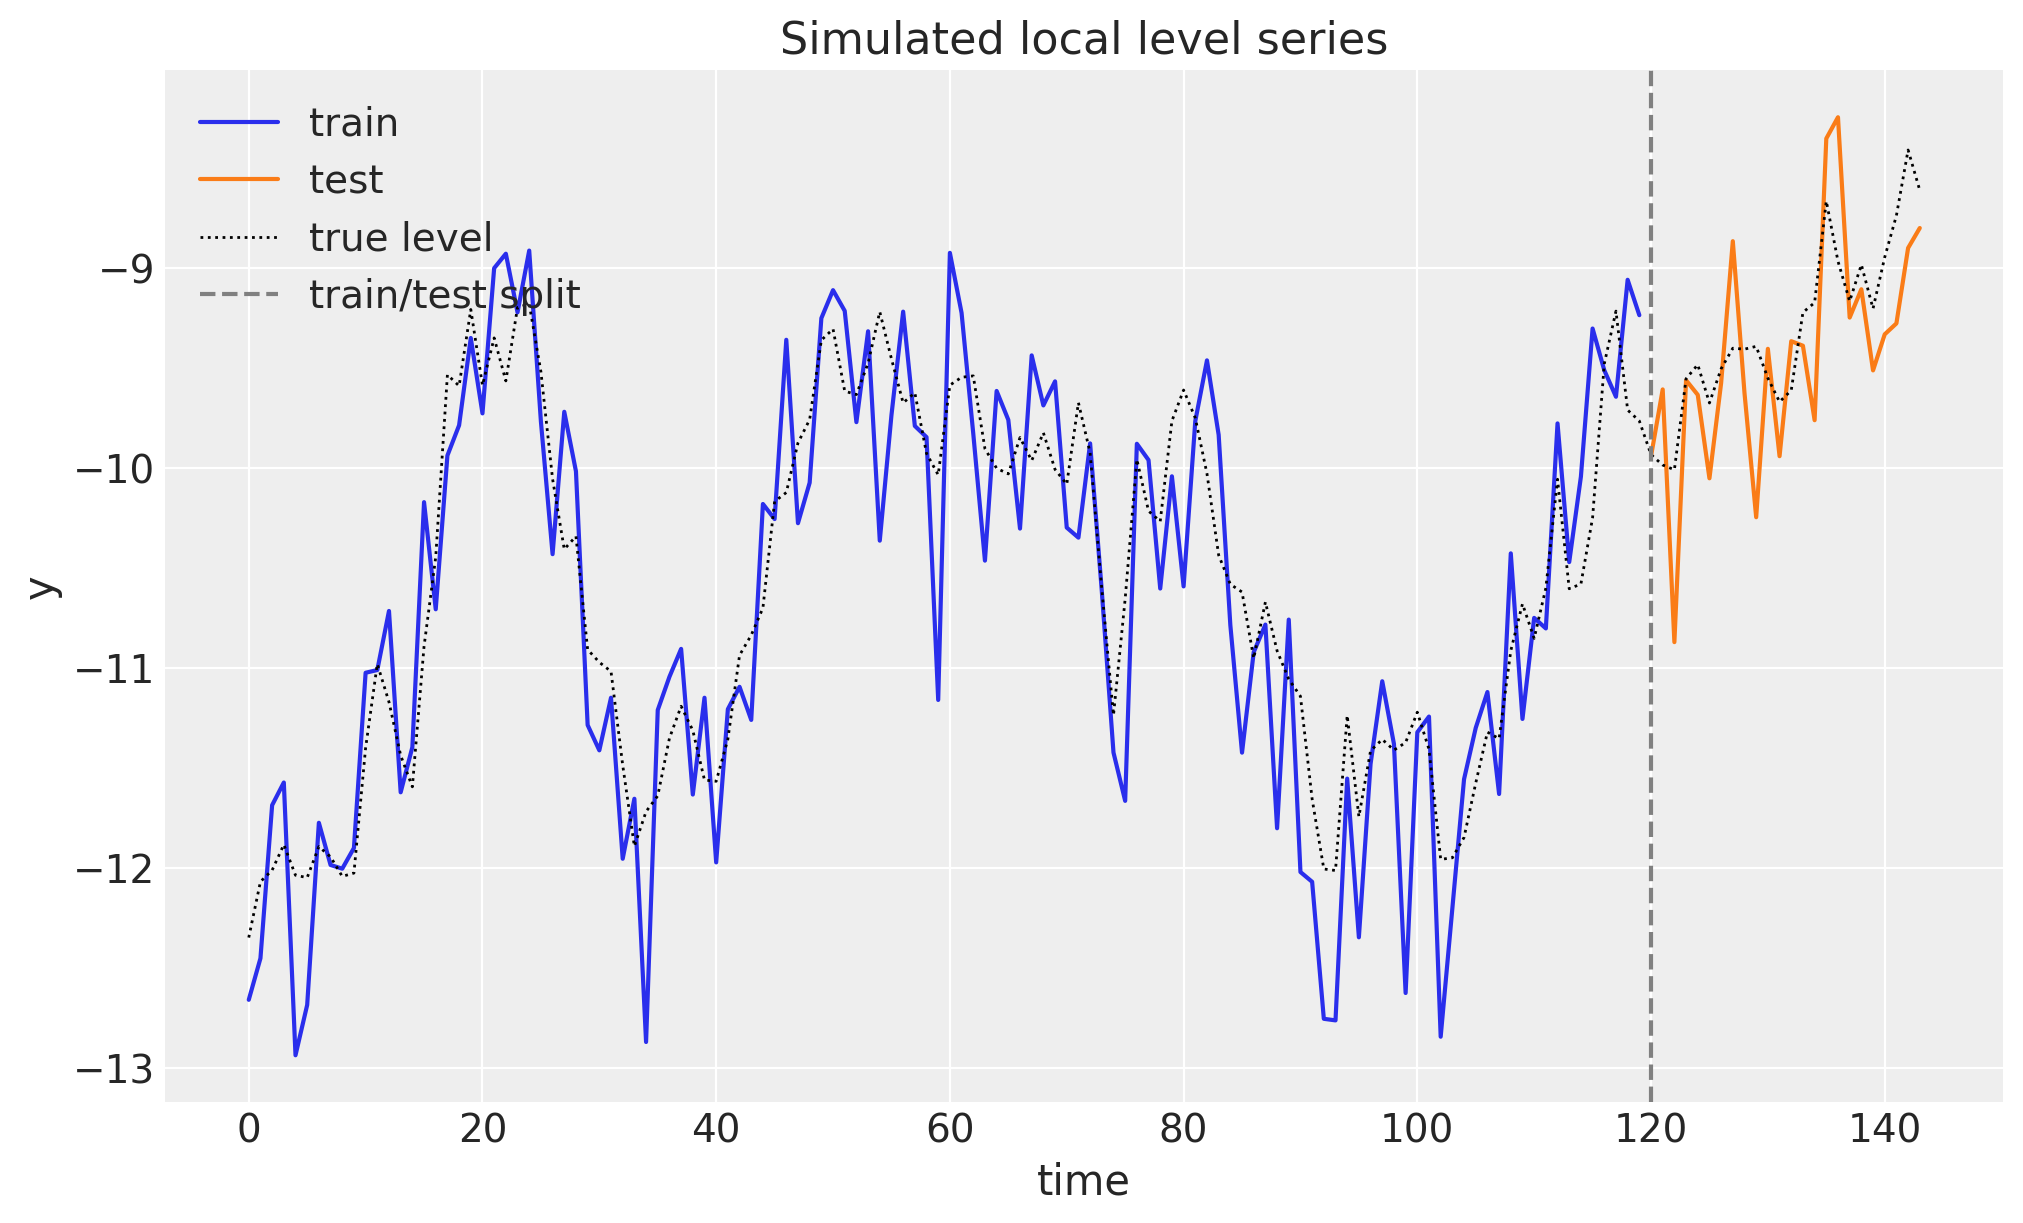

In [4]:
q_true, r_true = 0.3, 0.5
t_obs, future = 120, 24
duration = t_obs + future
time_index = np.arange(duration)
time_grid = np.arange(duration, dtype=np.float32)  # the block's default `times`

rng_key, rng_subkey = random.split(rng_key)
simulated = dsx.simulate(
    local_level_dynamics(jnp.asarray(q_true), jnp.asarray(r_true)),
    rng_key=rng_subkey,
    predict_times=jnp.asarray(time_grid),
)
assert simulated.observations is not None and simulated.states is not None  # raw simulation
y_full = simulated.observations[0]  # (duration, 1)
x_true = simulated.states[0, :, 0]  # (duration,)

train_data, test_data = y_full[:t_obs], y_full[t_obs:]
covariates_full = y_full  # the series doubles as the covariate
covariates_train = covariates_full[:t_obs]

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], train_data[:, 0], color="C0", label="train")
ax.plot(time_index[t_obs:], test_data[:, 0], color="C1", label="test")
ax.plot(time_index, x_true, color="black", lw=1, ls=":", label="true level")
ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated local level series", xlabel="time", ylabel="y");

The level moves as a random walk, and the observations scatter around it
with the larger noise scale $r$.

### Prior Predictive Checks

The priors on both scales are $\text{HalfNormal}(1)$, and the initial
level is $\text{Normal}(0, 10)$. Before fitting anything, we look at the
series these priors generate.

For a state space model the prior predictive is a forward simulation. We
write a small generative model in native `dynestyx` style (`dsx.sample`
with `predict_times` only) and run it under a `Simulator` with NumPyro’s
`Predictive`.

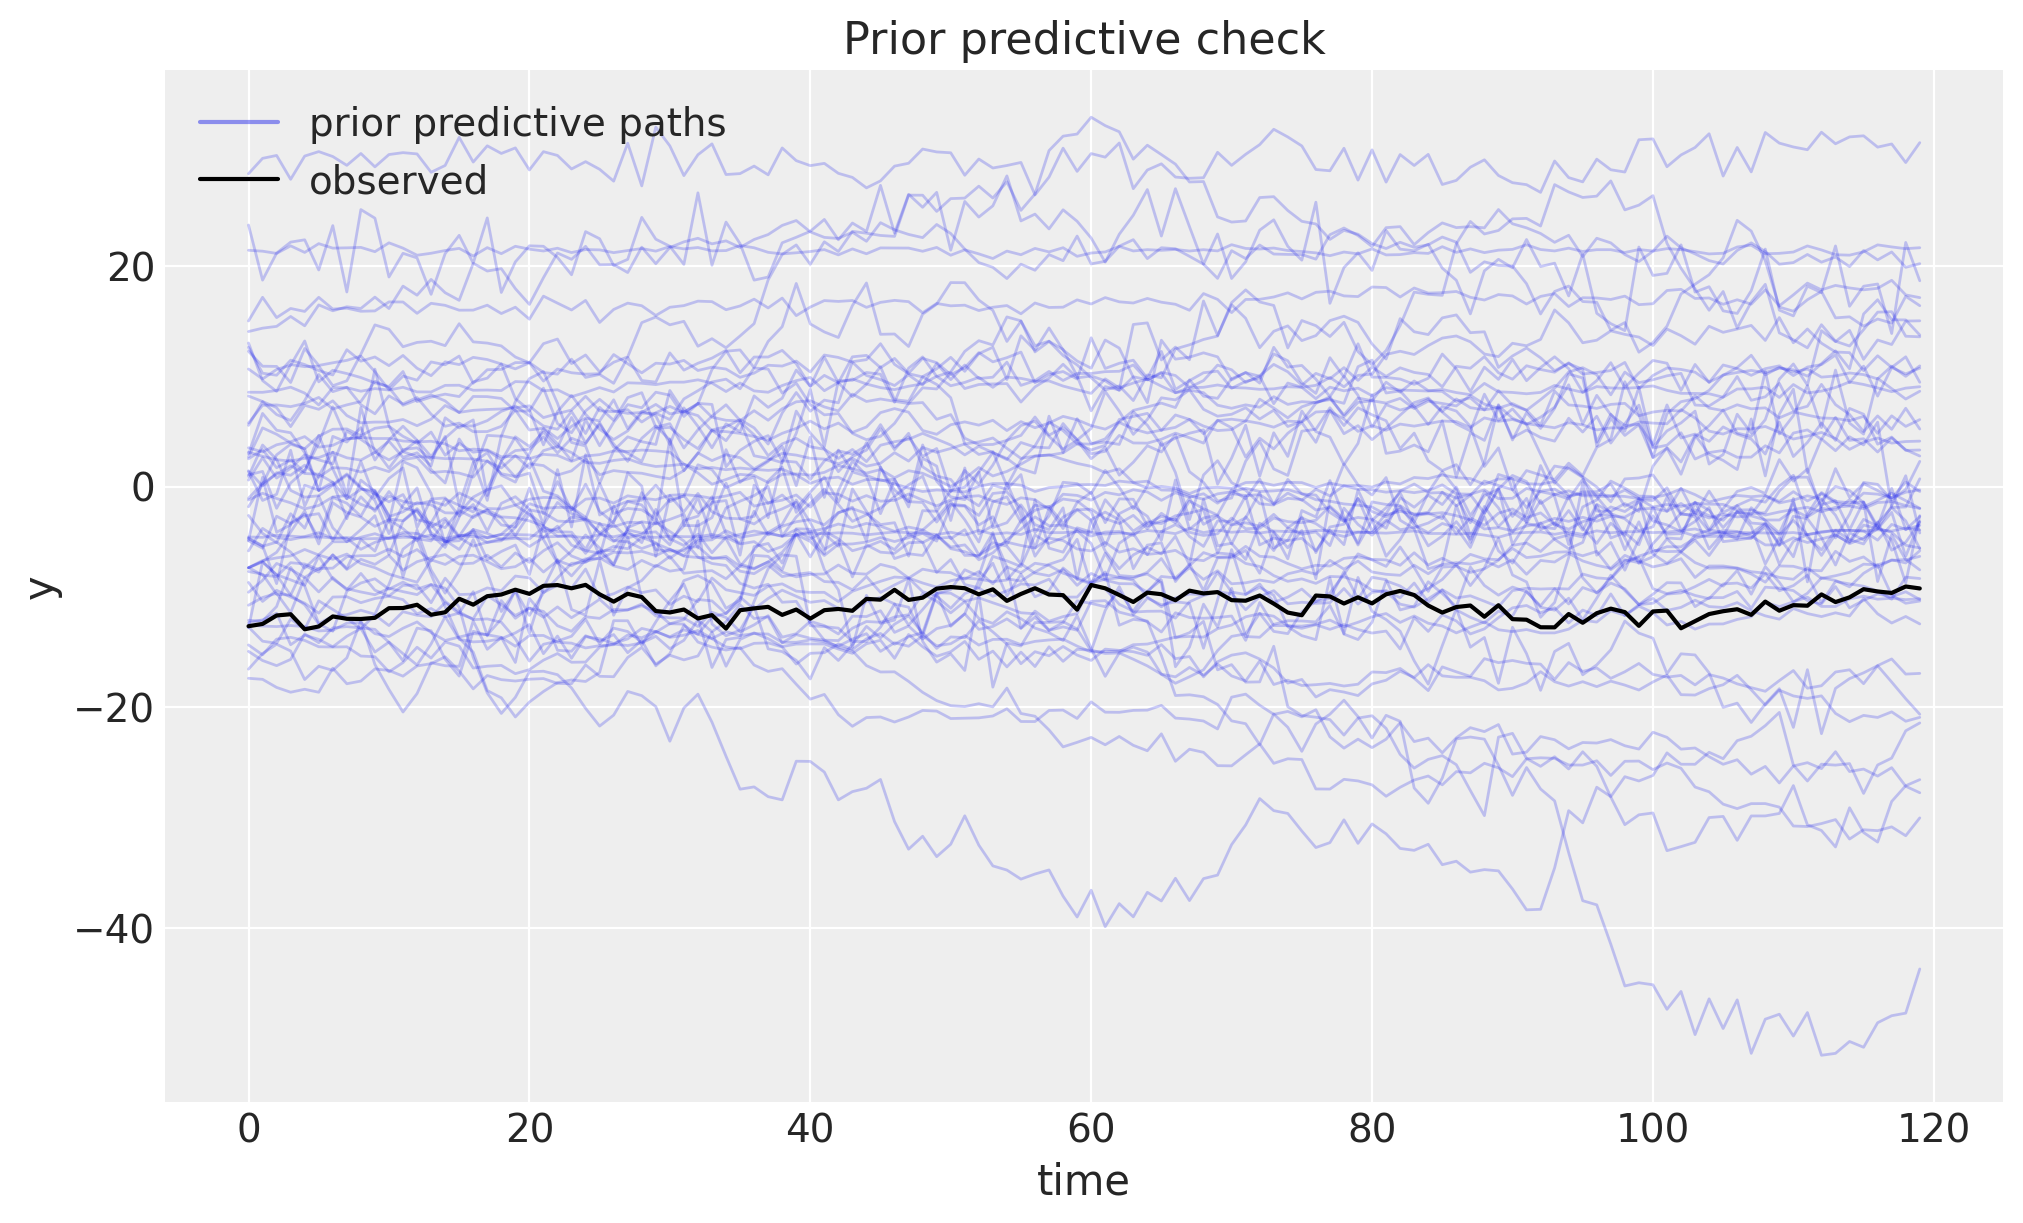

In [5]:
def local_level_prior(predict_times: Array) -> None:
    """Sample the scales from their priors and simulate a path from the local level model."""
    q = numpyro.sample("q", dist.HalfNormal(1.0))
    r = numpyro.sample("r", dist.HalfNormal(1.0))
    dsx.sample("f", local_level_dynamics(q, r), predict_times=predict_times)


rng_key, rng_subkey = random.split(rng_key)
with Simulator(n_simulations=1):
    prior_draws = Predictive(local_level_prior, num_samples=50)(
        rng_subkey, predict_times=jnp.asarray(time_grid[:t_obs])
    )
prior_paths = np.asarray(prior_draws["f_observations"][:, 0, :, 0])  # (50, t_obs)

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], prior_paths.T, color="C0", alpha=0.25, lw=1)
ax.plot([], [], color="C0", alpha=0.5, label="prior predictive paths")
ax.plot(time_index[:t_obs], train_data[:, 0], color="black", lw=1.5, label="observed")
ax.legend(loc="upper left")
ax.set(title="Prior predictive check", xlabel="time", ylabel="y");

The prior paths cover the observed series without being too wide, which
is good.

### Model Specification

All models are plain NumPyro functions `(covariates, data=None)` with
the same priors. They differ only in how the latent level enters the
trace.

The **direct** model is the idiomatic `numpyro_forecast` form.
[`innovations`](https://juanitorduz.github.io/numpyro_forecast/reference/models.innovations.html)
samples one innovation per time step (with a `LocScaleReparam` to soften
the funnel between $q$ and the path), the level is their cumulative sum
plus the initial level `x0`, and
[`predict`](https://juanitorduz.github.io/numpyro_forecast/reference/models.predict.html)
registers the likelihood. The sampler explores $t_{\text{obs}} + 3$
dimensions. One small difference with the `dynestyx` model: here the
first observation sees `x0` plus one innovation, while `dynestyx`
observes its initial state directly. With a $\text{Normal}(0, 10)$ prior
on the initial level this difference has no visible effect on the
posteriors.

The two **`dynestyx`** models share one function of the conditioner.
With a `LatentPathBuilder` the path is explicit: one sample site of
shape $(t_{\text{obs}}, 1)$ plus the two scales. With a `Smoother` the
Kalman smoother integrates the path out exactly, and the sampler
explores $2$ dimensions.

We use `KFSmootherConfig(filter_source="cd_dynamax")`, the exact
Rauch-Tung-Striebel smoother on the backend that was cheapest per
gradient in our measurements for a short series on the CPU. The
`filter_source="cuthbert"` backend adds support for missing observations
and time-varying parameters at a higher cost per gradient. We also build
the `Filter` variant of the model, with the matching `KFConfig()`, for
the cost measurement and the filtering view of the level below.

Every model registers a `level` deterministic site when it is called
without data. The direct model computes its level in place, and the
`dynestyx` models take it from the `x_in_sample` field of the block’s
result, which is the in-window state draw behind the in-sample
predictive. We read that site later to compare the three reconstructions
of the level.

In [6]:
def local_level_direct(covariates: Array, data: Array | None = None) -> None:
    """Local level model with the innovations sampled explicitly."""
    h = Horizon.from_data(covariates, data)
    q = numpyro.sample("q", dist.HalfNormal(1.0))
    r = numpyro.sample("r", dist.HalfNormal(1.0))
    x0 = numpyro.sample("x0", dist.Normal(0.0, 10.0))
    drift = innovations(h, "drift", dist.Normal(0.0, q), reparam=LocScaleReparam(0))
    level = x0 + jnp.cumsum(drift, axis=-2)
    if h.data is None:
        numpyro.deterministic("level", level)
    predict(h, dist.Normal(0.0, r), level)


def local_level_state_space(conditioner: StateSpaceHandler) -> ForecastModel:
    """Build the local level model conditioned by a dynestyx handler."""

    def model(covariates: Array, data: Array | None = None) -> None:
        h = Horizon.from_data(covariates, data)
        y = covariates[..., : h.t_obs, :]  # the observed window travels in the covariates
        q = numpyro.sample("q", dist.HalfNormal(1.0))
        r = numpyro.sample("r", dist.HalfNormal(1.0))
        result = state_space_series(h, "f", y, local_level_dynamics(q, r), conditioner=conditioner)
        if h.data is None:
            numpyro.deterministic("level", result.x_in_sample)

    return model


smoother = Smoother(smoother_config=KFSmootherConfig(filter_source="cd_dynamax"))
local_level_latent = local_level_state_space(LatentPathBuilder())
local_level_smoothed = local_level_state_space(smoother)
local_level_filtered = local_level_state_space(Filter(filter_config=KFConfig()))

### Model Fitting

We run the same sampler budget on the three models: $4$ chains of
$1{,}000$ warmup and $1{,}000$ sampling steps. The `num_steps` extra
field records the number of leapfrog steps of the sampling phase, one
gradient evaluation each, which is where NUTS spends its time. Warmup
steps are not counted, but they are part of the wall time.

`mcmc.get_samples()` returns the flat posterior dictionary that the
package drivers consume. For the `dynestyx` models it also carries the
deterministic sites their handlers record (`f_marginal_loglik`,
`f_state_path`, …).

In [7]:
def fit_nuts(
    rng_key: Array,
    model: ForecastModel,
    data: Array,
    covariates: Array,
    *,
    num_chains: int = 4,
    num_warmup: int = 1_000,
    num_samples: int = 1_000,
) -> tuple[MCMC, float]:
    """Fit ``model`` with NUTS and return the sampler and the wall time in seconds."""
    mcmc = MCMC(
        NUTS(model),
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        chain_method="sequential",
        progress_bar=False,
    )
    start = time.perf_counter()
    mcmc.run(rng_key, covariates, data, extra_fields=("num_steps",))
    jax.block_until_ready(mcmc.get_samples())
    return mcmc, time.perf_counter() - start


models = {
    "direct (innovations)": local_level_direct,
    "dynestyx, explicit path": local_level_latent,
    "dynestyx, Kalman smoother": local_level_smoothed,
}
fits: dict[str, tuple[MCMC, float]] = {}
for label, model in models.items():
    rng_key, rng_subkey = random.split(rng_key)
    fits[label] = fit_nuts(rng_subkey, model, train_data, covariates_train)
    print(f"{label:>26}: {fits[label][1]:6.1f} s")
posteriors = {label: mcmc.get_samples() for label, (mcmc, _) in fits.items()}

      direct (innovations):   11.3 s
   dynestyx, explicit path:    7.7 s
 dynestyx, Kalman smoother:   11.7 s

### Model Diagnostics

Before looking at the results, we check some diagnostics. The posteriors
of the two scales must agree with each other, because the three models
describe the same process and the smoother integrates the level out
exactly. What differs is the work the sampler has to do.

We collect the effective sample sizes and $\hat{R}$ with ArviZ (the
`(chain, draw)` layout comes from `get_samples(group_by_chain=True)`)
next to the wall time and the number of gradient evaluations.

In [8]:
def summarize_fit(mcmc: MCMC, label: str, wall: float) -> pd.DataFrame:
    """One-row table of posterior means, diagnostics and sampler cost for ``q`` and ``r``."""
    grouped = mcmc.get_samples(group_by_chain=True)
    tree = az.from_dict({"posterior": {name: np.asarray(grouped[name]) for name in ("q", "r")}})
    summary = az.summary(tree, var_names=["q", "r"], round_to="none")
    num_steps = int(np.asarray(mcmc.get_extra_fields(group_by_chain=True)["num_steps"]).sum())
    return pd.DataFrame(
        {
            "q mean": [summary.loc["q", "mean"]],
            "q sd": [summary.loc["q", "sd"]],
            "r mean": [summary.loc["r", "mean"]],
            "r sd": [summary.loc["r", "sd"]],
            "ess_bulk q": [summary.loc["q", "ess_bulk"]],
            "ess_bulk r": [summary.loc["r", "ess_bulk"]],
            "r_hat q": [summary.loc["q", "r_hat"]],
            "r_hat r": [summary.loc["r", "r_hat"]],
            "leapfrog steps": [num_steps],
            "wall time (s)": [wall],
        },
        index=[label],
    )


comparison = pd.concat([summarize_fit(mcmc, label, wall) for label, (mcmc, wall) in fits.items()])
print(f"truth: q = {q_true}, r = {r_true}")
comparison.round(
    {
        "q mean": 3,
        "q sd": 3,
        "r mean": 3,
        "r sd": 3,
        "ess_bulk q": 0,
        "ess_bulk r": 0,
        "r_hat q": 3,
        "r_hat r": 3,
        "wall time (s)": 1,
    }
)

truth: q = 0.3, r = 0.5

The three posterior means agree closely and the $\hat{R}$ values are
close to $1$. All three fits place the true values inside their bulk.
With $120$ observations the scales are only moderately well identified,
so a posterior mean one to one and a half standard deviations away from
the truth is not surprising.

The smoothed model reaches the largest effective sample size with a
small fraction of the gradient evaluations. It moves in a
$2$-dimensional posterior instead of a $123$-dimensional one, where the
likelihood still couples $q$ to every innovation after the non-centered
reparameterization.

The explicit path built by `dynestyx` sits between the two. It needs
fewer gradients than the direct model but mixes less well on $q$. A
plausible reason is that the builder samples the path in centered form
and has no reparameterization option, but we did not test this.

Each smoother gradient is more expensive (a Kalman pass over the window
instead of a sum of Gaussian log densities), so on a short series on the
CPU the wall times are similar. The advantage grows with the length of
the series: the dimension of the direct posterior grows with it, while
the dimension the smoother’s sampler explores stays $2$ and the cost of
a Kalman pass is linear in the length. On accelerators the `cuthbert`
backend can also use its associative (parallel-in-time) scan, which we
do not measure here.

We now measure the two costs that the building block section refers to:
a full model evaluation, which returns the marginal log likelihood and
the state estimates, and the gradient of the log density, which is what
NUTS and SVI evaluate. Both are compiled with `jax.jit` on the training
window.

In [9]:
def evaluation_cost(model: ForecastModel, site: str, num_evals: int = 1_000) -> float:
    """Milliseconds per compiled model evaluation, returning the log likelihood and ``site``."""

    def run(params: dict[str, Array]) -> tuple[Array, Array]:
        substituted = numpyro.handlers.substitute(model, data=params)
        tr = numpyro.handlers.trace(substituted).get_trace(covariates_train, train_data)
        return tr["f_marginal_loglik"]["value"], tr[site]["value"]

    return _timed(jax.jit(run), num_evals)


def gradient_cost(model: ForecastModel, num_evals: int = 1_000) -> float:
    """Milliseconds per compiled ``value_and_grad`` of the log density of ``model``."""

    def log_joint(params: dict[str, Array]) -> Array:
        return log_density(model, (covariates_train, train_data), {}, params)[0]

    return _timed(jax.jit(jax.value_and_grad(log_joint)), num_evals)


def _timed(fn: Callable[[dict[str, Array]], Any], num_evals: int) -> float:
    """Average wall time in milliseconds of ``fn`` at the true scales, after compilation."""
    params = {"q": jnp.asarray(q_true), "r": jnp.asarray(r_true)}
    jax.block_until_ready(fn(params))
    start = time.perf_counter()
    for _ in range(num_evals):
        out = fn(params)
    jax.block_until_ready(out)
    return (time.perf_counter() - start) / num_evals * 1e3


pd.DataFrame(
    {
        "evaluation (ms)": {
            "Filter": evaluation_cost(local_level_filtered, "f_filtered_states_mean"),
            "Smoother": evaluation_cost(local_level_smoothed, "f_smoothed_states_mean"),
        },
        "gradient (ms)": {
            "Filter": gradient_cost(local_level_filtered),
            "Smoother": gradient_cost(local_level_smoothed),
        },
    }
).round(3)

The full evaluation is more expensive under the `Smoother`, which is the
backward pass. The gradient costs the same under both handlers, because
the marginal log likelihood depends on the forward pass only and JAX
drops the unused backward pass from the compiled gradient.

Next, we overlay the three posteriors of the two scales.

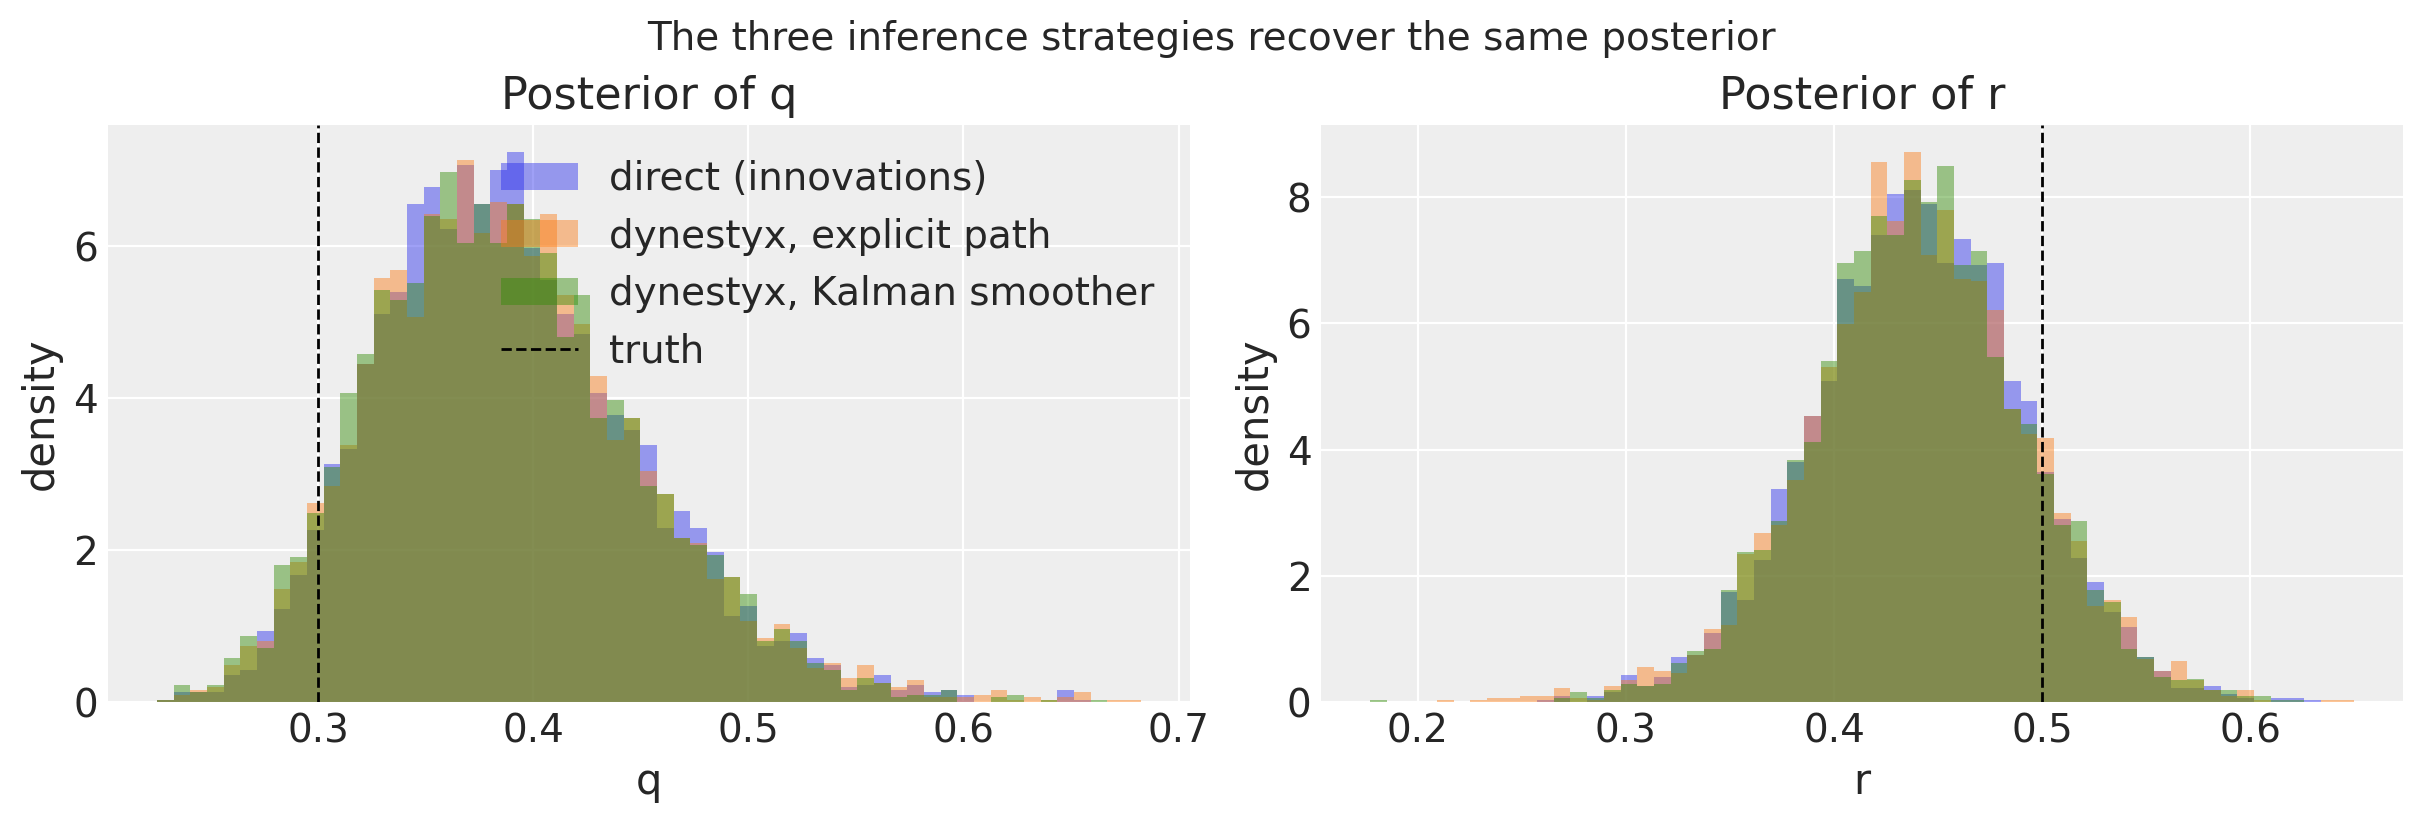

In [10]:
colors = {label: f"C{i}" for i, label in enumerate(models)}
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
for ax, name, truth in zip(axes, ("q", "r"), (q_true, r_true), strict=True):
    values = {label: np.asarray(post[name]) for label, post in posteriors.items()}
    bins = np.linspace(
        min(v.min() for v in values.values()), max(v.max() for v in values.values()), 60
    )
    for label, v in values.items():
        ax.hist(v, bins=bins, density=True, alpha=0.45, color=colors[label], label=label)
    ax.axvline(truth, color="black", ls="--", lw=1, label="truth")
    ax.set(title=f"Posterior of {name}", xlabel=name, ylabel="density")
axes[0].legend(loc="upper right")
fig.suptitle("The three inference strategies recover the same posterior", fontsize=14);

The three histograms lie on top of each other, and the truth sits inside
the bulk of each posterior.

### Forecast

Forecasting uses the package’s
[`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html)
driver in all three cases. It runs `Predictive` over the full-horizon
covariates and returns the `"forecast"` site with one path per posterior
draw.

For the direct model the in-sample innovations are replayed from the
posterior and the future ones are drawn from the prior. For the
`dynestyx` models every draw conditions again on the training window
with its own $(q, r)$ (the smoother recomputes the smoothing
distribution, the builder reconstructs the posterior path), and the
simulator rolls the conditioned state forward.

This re-conditioning is one vectorized pass over the window per draw,
which is cheap here. For long windows or particle filters, the design
document records a cached-anchor rollout as the alternative.

The driver is jitted and vectorized over the draws, and the `dynestyx`
handlers inside the model run under that `jit` and `vmap` without
special treatment. We define two small helpers for the HDI bands and
their labels, then forecast with the three posteriors.

In [11]:
def hdi_over_draws(draws: Array | np.ndarray, prob: float) -> tuple[np.ndarray, np.ndarray]:
    """Lower and upper HDI bounds over the sample axis of ``(sample, time, 1)`` draws."""
    da = xr.DataArray(np.asarray(draws)[..., 0], dims=["sample", "time"])
    hdi = az.hdi(da, prob=prob, dim="sample")  # (time, ci_bound)
    return hdi.sel(ci_bound="lower").to_numpy(), hdi.sel(ci_bound="upper").to_numpy()


def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = {0.5: 0.6, 0.94: 0.3}  # 50% band darker, 94% band lighter

forecasts: dict[str, Array | np.ndarray] = {}
for label, model in models.items():
    rng_key, rng_subkey = random.split(rng_key)
    forecasts[label] = forecast(rng_subkey, model, posteriors[label], train_data, covariates_full)
    print(f"{label:>26}: forecast draws {forecasts[label].shape}")

      direct (innovations): forecast draws (4000, 24, 1)
   dynestyx, explicit path: forecast draws (4000, 24, 1)
 dynestyx, Kalman smoother: forecast draws (4000, 24, 1)

We plot the three forecast fans with their $50\%$ and $94\%$ HDI bands.

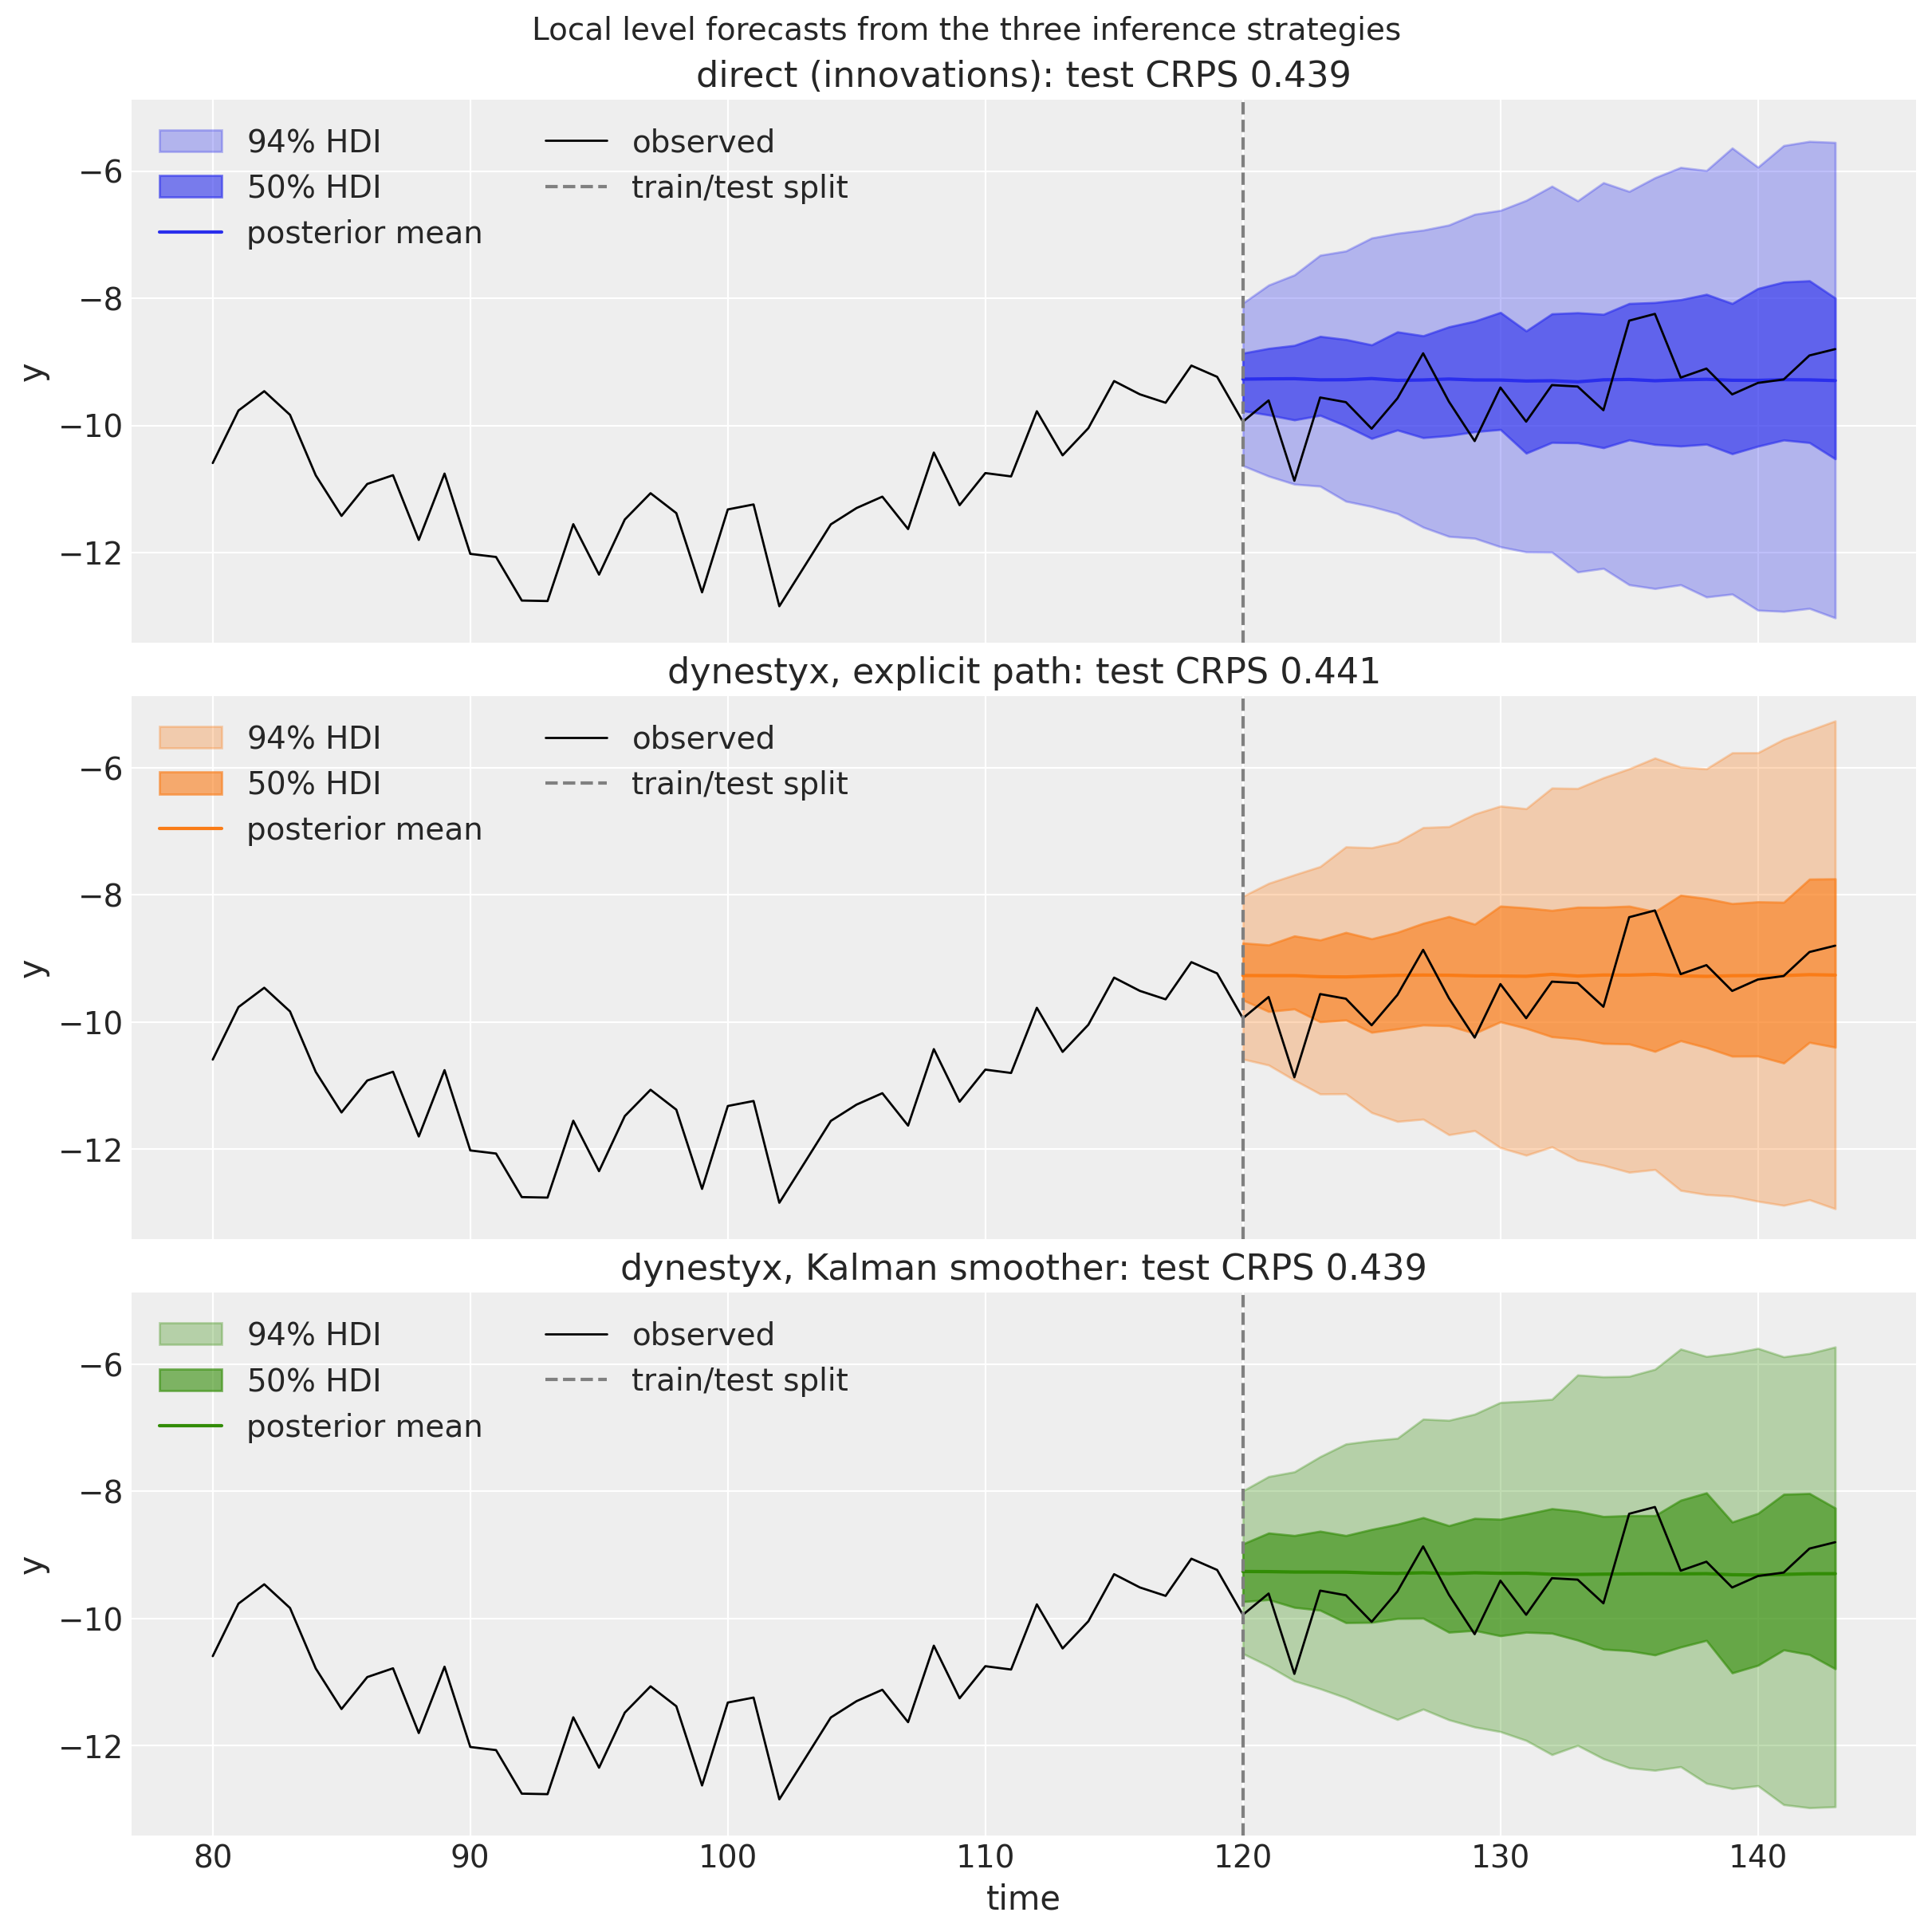

In [12]:
fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, sharey=True, layout="constrained"
)
future_index = time_index[t_obs:]
for ax, (label, draws) in zip(axes, forecasts.items(), strict=True):
    color = colors[label]
    for prob in sorted(hdi_probs, reverse=True):
        lower, upper = hdi_over_draws(draws, prob)
        ax.fill_between(
            future_index, lower, upper, color=color, alpha=hdi_alphas[prob], label=hdi_label(prob)
        )
    ax.plot(
        future_index, np.asarray(draws).mean(axis=0)[:, 0], color=color, label="posterior mean"
    )
    ax.plot(
        time_index[t_obs - 40 :], y_full[t_obs - 40 :, 0], color="black", lw=1, label="observed"
    )
    ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
    crps = eval_crps(draws, test_data)
    ax.set(title=f"{label}: test CRPS {crps:.3f}", ylabel="y")
    ax.legend(loc="upper left", ncol=2)
axes[-1].set(xlabel="time")
fig.suptitle("Local level forecasts from the three inference strategies", fontsize=14);

The three fans are the same forecast up to Monte Carlo error. The
`dynestyx` models are not approximations of the direct one: they are the
same model with a different parameterization for the sampler.

The same comparison in tabular form: point accuracy through MAE and
RMSE, the CRPS as a proper score for the whole predictive distribution,
and the empirical coverage of the central $50\%$ and $94\%$ intervals.

In [13]:
metric_fns = {
    "MAE": eval_mae,
    "RMSE": eval_rmse,
    "CRPS": eval_crps,
    "coverage (50%)": partial(eval_coverage, alpha=0.5),
    "coverage (94%)": partial(eval_coverage, alpha=0.94),
}
pd.DataFrame(
    {
        label: {name: float(fn(draws, test_data)) for name, fn in metric_fns.items()}
        for label, draws in forecasts.items()
    }
).round(3)

The metrics on the held-out window agree as well.

### Posterior Predictive Checks

We now look at the in-sample posterior predictive. Because the observed
window travels in the covariates, the package’s
[`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html)
applies to the `dynestyx` models as it does to any other. It restores
the `(chain, draw)` structure, samples the in-sample posterior
predictive by calling the model without data, and, because we pass the
full-horizon covariates, writes the forecast into the `predictions`
group.

Recall that `data=None` is a mode switch. The window still reaches the
model through the covariates, so the in-sample predictive is the
smoothing predictive $p(y_t^{\text{rep}} \mid y_{1:T}, \theta)$ and not
a prior predictive.

The three models produce it in three ways. The direct model replays its
sampled path and adds observation noise. Under the `LatentPathBuilder`
the block takes the posterior path that `dynestyx` reconstructs and adds
the same noise. Under the `Smoother` the block draws every in-window
state from the smoothing distribution $p(x_t \mid y_{1:T}, \theta)$ and
adds the noise. The first two are joint draws of the whole path, the
third is a set of per-step marginal draws. At every single step the
three are the same distribution, which is all the bands below show.

In [14]:
trees: dict[str, xr.DataTree] = {}
for label, model in models.items():
    rng_key, rng_subkey = random.split(rng_key)
    trees[label] = to_datatree(
        rng_subkey, model, posteriors[label], train_data, covariates_full, num_chains=4
    )
trees["dynestyx, Kalman smoother"]

<xarray.DataTree>
Group: /
│ Attributes:
│ inference_library: numpyro
│ creation_library: numpyro_forecast
│ sample_dims: ['chain', 'draw']
├── Group: /posterior
│ Dimensions: (chain: 4, draw: 1000,
│ f_smoothed_states_cov_dim_0: 120,
│ f_smoothed_states_cov_dim_1: 1,
│ f_smoothed_states_cov_dim_2: 1,
│ f_smoothed_states_cov_diag_dim_0: 120,
│ f_smoothed_states_cov_diag_dim_1: 1,
│ f_smoothed_states_mean_dim_0: 120,
│ f_smoothed_states_mean_dim_1: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 ... 997 998 999
│ * f_smoothed_states_cov_dim_0 (f_smoothed_states_cov_dim_0) int64 960B ...
│ * f_smoothed_states_cov_dim_1 (f_smoothed_states_cov_dim_1) int64 8B 0
│ * f_smoothed_states_cov_dim_2 (f_smoothed_states_cov_dim_2) int64 8B 0
│ * f_smoothed_states_cov_diag_dim_0 (f_smoothed_states_cov_diag_dim_0) int64 960B ...
│ * f_smoothed_states_cov_diag_dim_1 (f_smoothed_states_cov_diag_dim_1) int64 8B ...
│ * f_smoothed_states_mean_dim_0 (f_smoothed_states_mean_dim_0) int64 960B ...
│ * f_smoothed_states_mean_dim_1 (f_smoothed_states_mean_dim_1) int64 8B 0
│ Data variables:
│ f_marginal_loglik (chain, draw) float32 16kB -124.9 ... -...
│ f_smoothed_states_cov (chain, draw, f_smoothed_states_cov_dim_0, f_smoothed_states_cov_dim_1, f_smoothed_states_cov_dim_2) float32 2MB ...
│ f_smoothed_states_cov_diag (chain, draw, f_smoothed_states_cov_diag_dim_0, f_smoothed_states_cov_diag_dim_1) float32 2MB ...
│ f_smoothed_states_mean (chain, draw, f_smoothed_states_mean_dim_0, f_smoothed_states_mean_dim_1) float32 2MB ...
│ q (chain, draw) float32 16kB 0.3207 ... 0...
│ r (chain, draw) float32 16kB 0.4482 ... 0...
│ Attributes:
│ created_at: 2026-09-29T20:43:10.389684+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.1
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
├── Group: /posterior_predictive
│ Dimensions: (chain: 4, draw: 1000, time: 120, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│ * time (time) int64 960B 0 1 2 3 4 5 6 7 ... 113 114 115 116 117 118 119
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (chain, draw, time, obs_dim) float32 2MB -12.35 -11.79 ... -9.208
│ Attributes:
│ created_at: 2026-09-29T20:43:10.888287+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.1
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
├── Group: /observed_data
│ Dimensions: (time: 120, obs_dim: 1)
│ Coordinates:
│ * time (time) int64 960B 0 1 2 3 4 5 6 7 ... 113 114 115 116 117 118 119
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (time, obs_dim) float32 480B -12.66 -12.45 -11.69 ... -9.059 -9.236
│ Attributes:
│ created_at: 2026-09-29T20:43:10.888508+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.1
│ creation_library_language: Python
│ sample_dims: []
├── Group: /constant_data
│ Dimensions: (time: 120, covariate_dim: 1)
│ Coordinates:
│ * time (time) int64 960B 0 1 2 3 4 5 6 ... 114 115 116 117 118 119
│ * covariate_dim (covariate_dim) int64 8B 0
│ Data variables:
│ covariates (time, covariate_dim) float32 480B -12.66 -12.45 ... -9.236
│ Attributes:
│ created_at: 2026-09-29T20:43:10.888669+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.1
│ creation_library_language: Python
│ sample_dims: []
├── Group: /predictions
│ Dimensions: (chain: 4, draw: 1000, time: 24, obs_dim: 1)
│ Coordinates:
│ * chain (chain) int64 32B 0 1 2 3
│ * draw (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│ * time (time) int64 192B 120 121 122 123 124 125 ... 139 140 141 142 143
│ * obs_dim (obs_dim) int64 8B 0
│ Data variables:
│ obs (chain, draw, time, obs_dim) float32 384kB -10.23 -9.461 ... -6.908
│ Attributes:
│ created_at: 2026-09-29T20:43:10.915566+00:00
│ creation_library: ArviZ
│ creation_library_version: 1.3.1
│ creation_library_language: Python
│ sample_dims: ['chain', 'draw']
└── Group: /predictions_

The tree carries the `posterior`, `posterior_predictive`,
`observed_data` and `constant_data` groups and, because the covariates
extend past the data, the `predictions` and `predictions_constant_data`
groups, as for any other model of the package. We plot the three
in-sample bands.

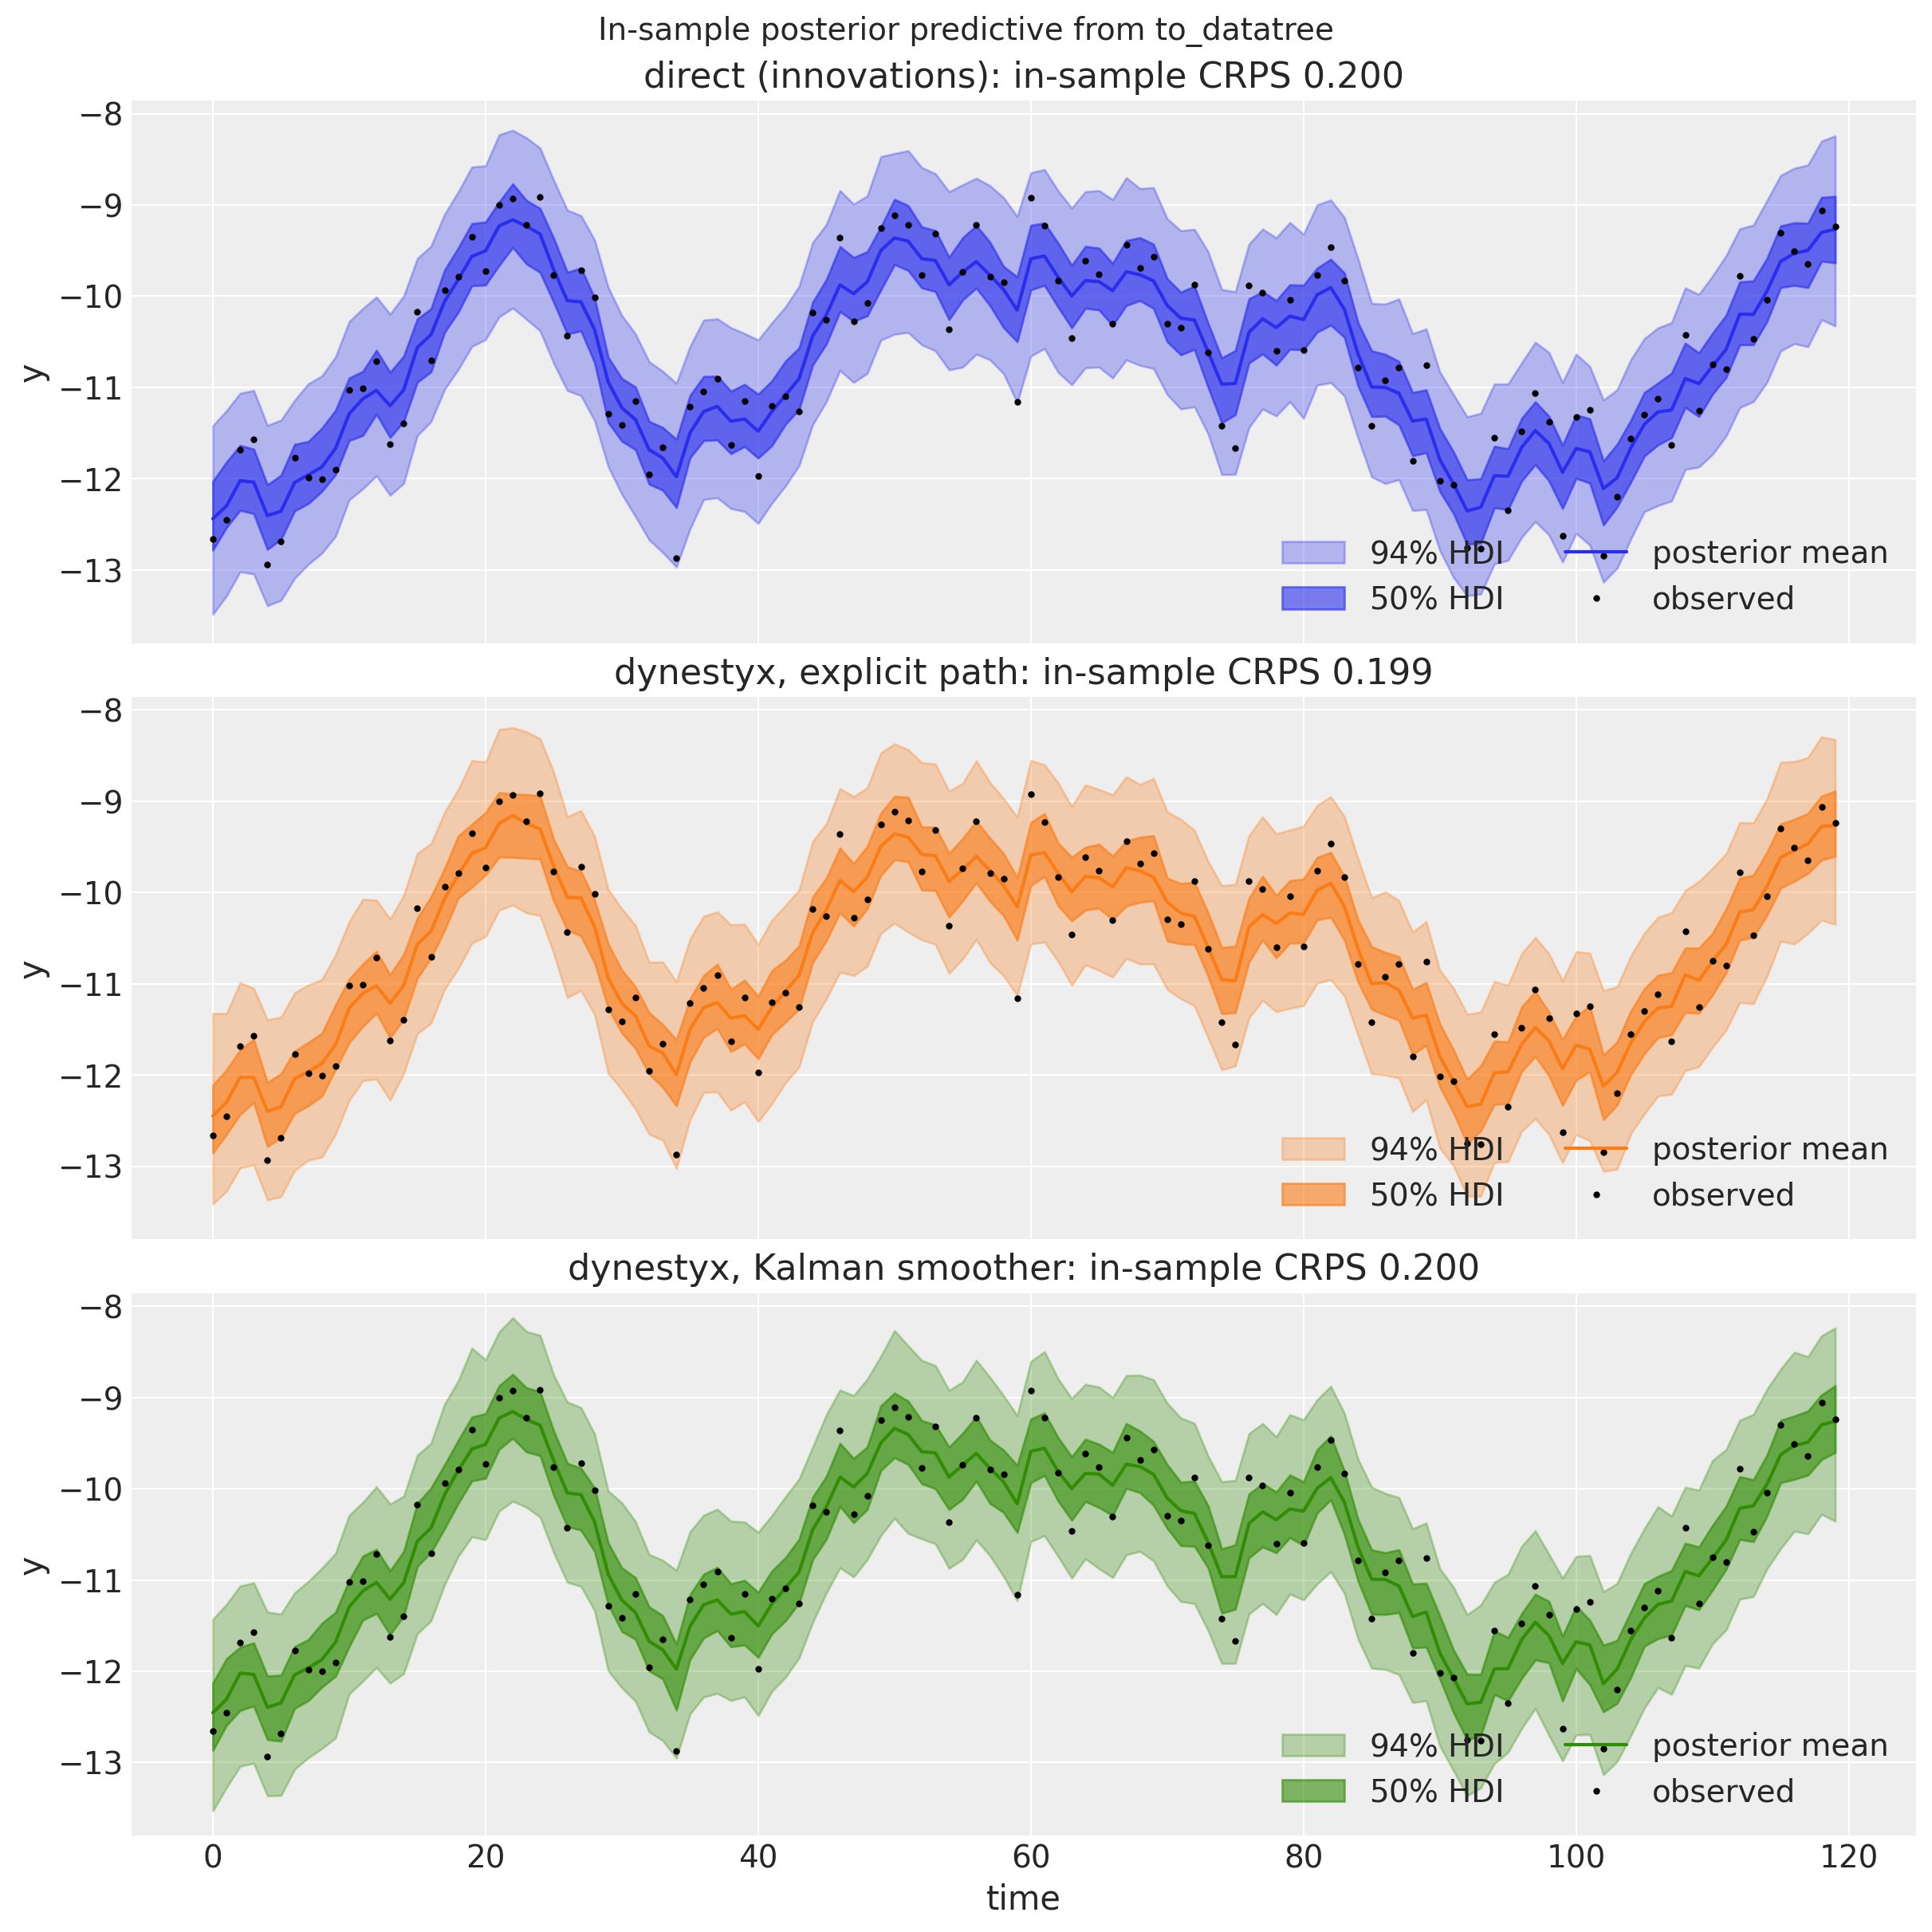

In [15]:
def stacked_draws(tree: xr.DataTree, group: str, var: str) -> np.ndarray:
    """Stack the ``(chain, draw)`` dims of ``tree[group][var]`` into a leading sample axis."""
    return (
        tree[group]
        .dataset[var]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "time", "obs_dim")
        .to_numpy()
    )


fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, sharey=True, layout="constrained"
)
for ax, (label, tree) in zip(axes, trees.items(), strict=True):
    in_sample = stacked_draws(tree, "posterior_predictive", "obs")
    color = colors[label]
    for prob in sorted(hdi_probs, reverse=True):
        lower, upper = hdi_over_draws(in_sample, prob)
        ax.fill_between(
            time_index[:t_obs],
            lower,
            upper,
            color=color,
            alpha=hdi_alphas[prob],
            label=hdi_label(prob),
        )
    ax.plot(time_index[:t_obs], in_sample.mean(axis=0)[:, 0], color=color, label="posterior mean")
    ax.plot(time_index[:t_obs], train_data[:, 0], ".", color="black", ms=4, label="observed")
    crps = eval_crps(in_sample, train_data)
    ax.set(title=f"{label}: in-sample CRPS {crps:.3f}", ylabel="y")
    ax.legend(loc="lower right", ncol=2)
axes[-1].set(xlabel="time")
fig.suptitle("In-sample posterior predictive from to_datatree", fontsize=14);

The three bands coincide and the in-sample CRPS values agree closely.
The `LatentPathBuilder` conditioner serves the in-sample predictive as
well as the smoother does, so both `dynestyx` strategies work with
`predict_in_sample` and `to_datatree`.

### Latent Level Reconstruction

This section separates two claims that are easy to mix up.

**The parameter posterior is the same under a `Filter` and a
`Smoother`.** Both handlers put the same number in the trace, the
marginal log likelihood $\log p(y_{1:T} \mid \theta)$ of the window,
because the Kalman smoother reads it from its forward filtering pass.
The posterior $p(\theta \mid y_{1:T})$ is therefore the same under both
handlers. We confirm this on the fitted model with
`numpyro.infer.util.log_density`, at one parameter value.

In [16]:
smoothed_posterior = posteriors["dynestyx, Kalman smoother"]
posterior_mean = {name: smoothed_posterior[name].mean() for name in ("q", "r")}
handlers = {"Filter": local_level_filtered, "Smoother": local_level_smoothed}
for handler, handler_model in handlers.items():
    log_joint, _ = log_density(handler_model, (covariates_train, train_data), {}, posterior_mean)
    print(f"{handler:>8} handler: log joint density at the posterior mean {float(log_joint):.6f}")

  Filter handler: log joint density at the posterior mean -125.142899
Smoother handler: log joint density at the posterior mean -125.142899

The two values agree. The draws we already have are draws from the
posterior of either model, and we can read them under the other handler
without refitting.

**The distributions over the states are different.** The filtering
distribution $p(x_t \mid y_{1:t}, \theta)$ conditions on the
observations up to step $t$ only. The smoothing distribution
$p(x_t \mid y_{1:T}, \theta)$ conditions on the whole window at every
step. They answer different questions about the state, and only the
second one gives the in-sample predictive of the section above.

Every model registers a `level` site when it is called without data.
Calling `Predictive` with the posterior draws and the training
covariates only, and asking for that site, gives one level path per
posterior draw. The direct model replays `x0` plus the cumulative sum of
the sampled `drift`, the builder returns its posterior path, and the
smoother draws from the smoothing distribution, the last two through the
same `x_in_sample` field of the block’s result. All three condition on
the whole window, so all three are smoothing reconstructions.

The filtered level needs one more step, because a `Filter` conditioner
has no in-sample mode. Instead, we record the `f_filtered_states_*`
sites with `Predictive` under the `Filter` model defined above, using
the draws of the smoothed fit. Drawing one level per posterior draw from
those per-step Gaussians mixes the state uncertainty and the parameter
uncertainty into a single band, as the `level` site does for the other
three.

In [17]:
levels: dict[str, np.ndarray] = {}
for label, model in models.items():
    rng_key, rng_subkey = random.split(rng_key)
    level_site = Predictive(model, posterior_samples=posteriors[label], return_sites=["level"])
    levels[label] = np.asarray(level_site(rng_subkey, covariates_train)["level"])
    print(f"{label:>26}: level draws {levels[label].shape}")

rng_key, key_sites, key_draw = random.split(rng_key, 3)
filtered_sites = Predictive(
    local_level_filtered,
    posterior_samples=posteriors["dynestyx, Kalman smoother"],
    return_sites=["f_filtered_states_mean", "f_filtered_states_cov_diag"],
)(key_sites, covariates_train, train_data)
filtered_mean = np.asarray(filtered_sites["f_filtered_states_mean"])
filtered_sd = np.sqrt(np.asarray(filtered_sites["f_filtered_states_cov_diag"]))
filtered_level = filtered_mean + filtered_sd * np.asarray(
    random.normal(key_draw, filtered_mean.shape)
)

      direct (innovations): level draws (4000, 120, 1)
   dynestyx, explicit path: level draws (4000, 120, 1)
 dynestyx, Kalman smoother: level draws (4000, 120, 1)

The simulation gives us the true level, so we can score the four
reconstructions against it. The smoother conditions on more data than
the filter, so it should reconstruct the state better, both as a point
estimate (RMSE) and as a distribution (CRPS).

In [18]:
true_level = x_true[:t_obs, None]
level_metrics = {"RMSE": eval_rmse, "CRPS": eval_crps}
reconstructions = {"dynestyx, Kalman filter": filtered_level, **levels}
pd.DataFrame(
    {
        label: {name: float(fn(draws, true_level)) for name, fn in level_metrics.items()}
        for label, draws in reconstructions.items()
    }
).round(3)

We plot the filtered and smoothed levels in the top panel, and the three
`level` sites in the bottom panel.

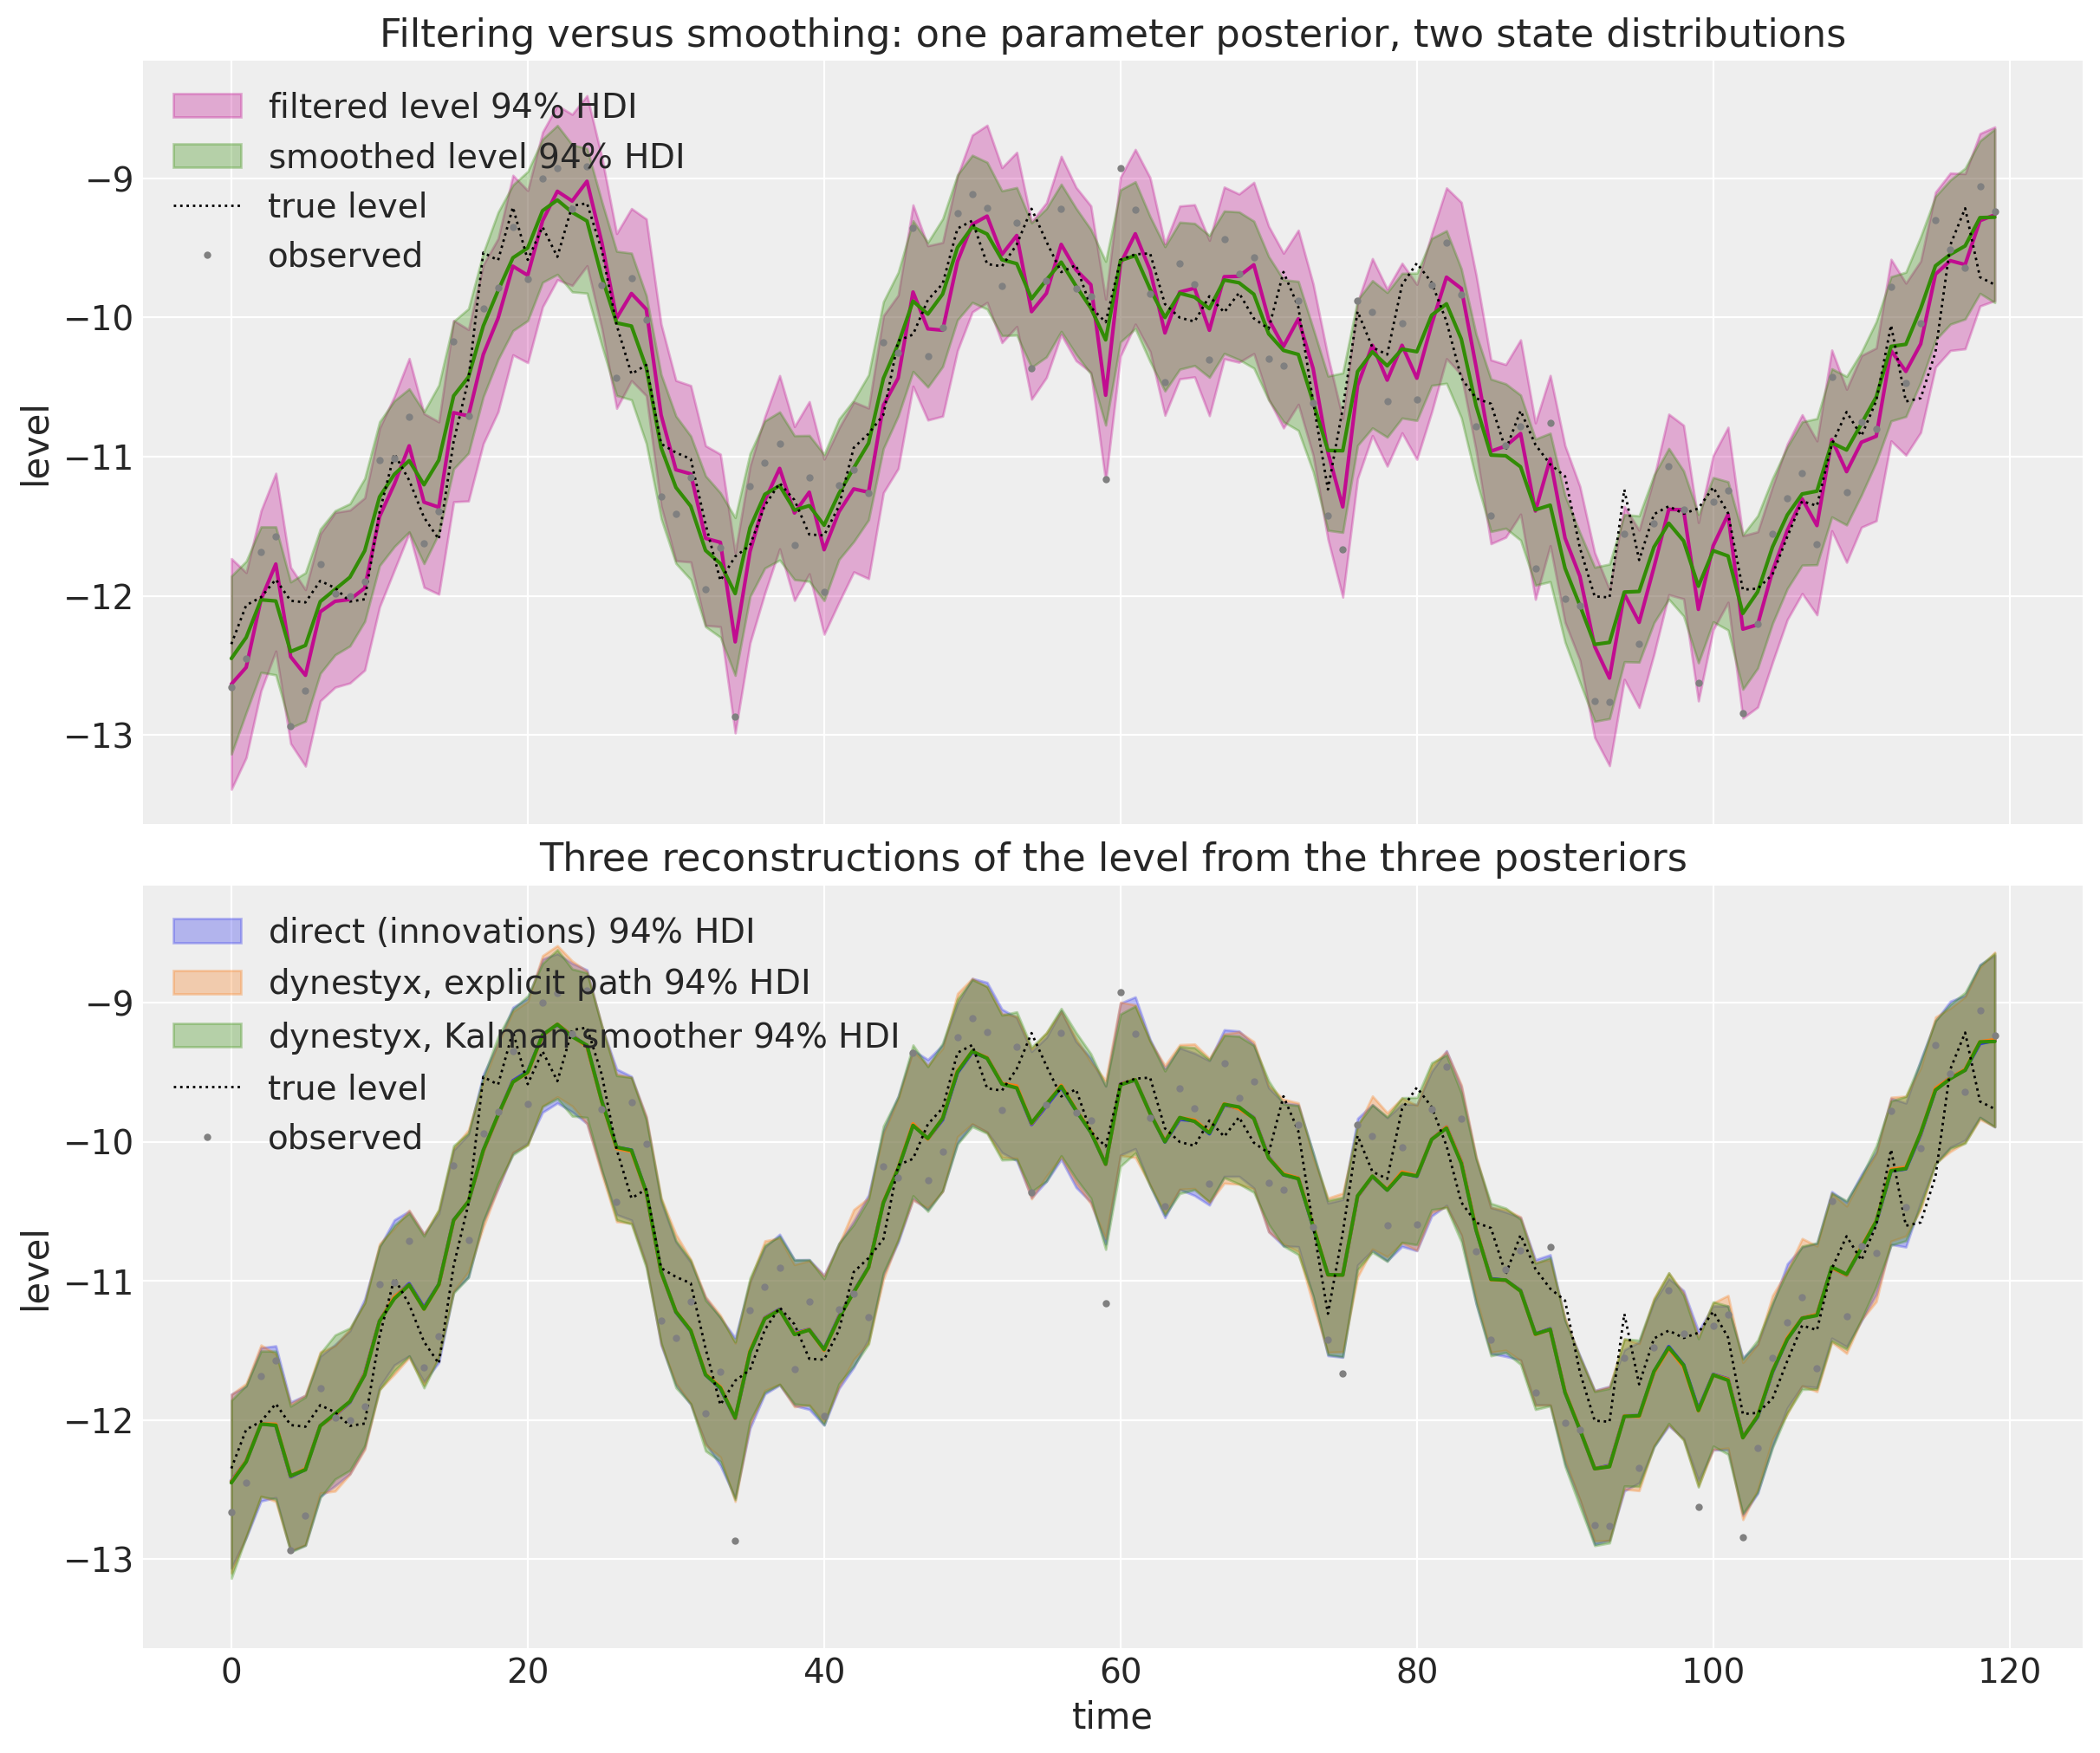

In [19]:
panels = {
    "Filtering versus smoothing: one parameter posterior, two state distributions": {
        "filtered level": ("C3", filtered_level),
        "smoothed level": (
            colors["dynestyx, Kalman smoother"],
            levels["dynestyx, Kalman smoother"],
        ),
    },
    "Three reconstructions of the level from the three posteriors": {
        label: (colors[label], draws) for label, draws in levels.items()
    },
}
fig, axes = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 10), sharex=True, sharey=True, layout="constrained"
)
for ax, (title, bands) in zip(axes, panels.items(), strict=True):
    for label, (color, draws) in bands.items():
        lower, upper = hdi_over_draws(draws, 0.94)
        ax.fill_between(
            time_index[:t_obs],
            lower,
            upper,
            color=color,
            alpha=0.3,
            label=hdi_label(0.94, prefix=f"{label} "),
        )
        ax.plot(time_index[:t_obs], draws.mean(axis=0)[:, 0], color=color, lw=1.5)
    ax.plot(time_index[:t_obs], x_true[:t_obs], color="black", lw=1, ls=":", label="true level")
    ax.plot(time_index[:t_obs], train_data[:, 0], ".", color="gray", ms=4, label="observed")
    ax.legend(loc="upper left")
    ax.set(title=title, ylabel="level")
axes[-1].set(xlabel="time");

In the top panel the filtered band is wider at every step, and widest at
the start of the window, where few observations have entered it. Its
mean reacts to each new observation and lags the level. The smoothed
band conditions on the whole window at every step, so it is narrower and
closer to the truth, and the table above confirms it with the lower RMSE
and CRPS against the true level. The two bands are two different
distributions over the state, not two views of one distribution.

In the bottom panel the three reconstructions coincide. The direct
model, the explicit path built by `dynestyx` and the smoother recover
the same level from the same posterior, and the two `dynestyx` models
did so through the same `x_in_sample` field.

## Seasonal Regression Model

The package routes everything a model needs at prediction time through
the `covariates` array, which spans the full horizon. In this example
the array carries two things. The observed series sits in its first
column, which the model reads back as the observed window. Fourier
features fill the remaining columns, which the block forwards to
`dynestyx` as control inputs (`ctrl_values`) on a time grid that covers
both the observed and the predicted steps.

The seasonal pattern enters the observation equation as a regression on
those features with coefficients $\beta$. With $u_t$ the row of features
at step $t$:

$$
\begin{align*}
x_t &= x_{t-1} + w_t, \qquad w_t \sim \text{Normal}(0, q), \\
y_t &= x_t + \beta^\top u_t + v_t, \qquad v_t \sim \text{Normal}(0, r).
\end{align*}
$$

In `dynestyx` terms $\beta^\top u_t$ is the `D` matrix of
`LTI_discrete`, which infers the control dimension from `D` since
`dynestyx` $0.5.1$.

### Generate Data

We simulate the series with the same scales, the true coefficients
`beta_true` and a period of $12$ steps with $2$ harmonics, again with
`dsx.simulate`.

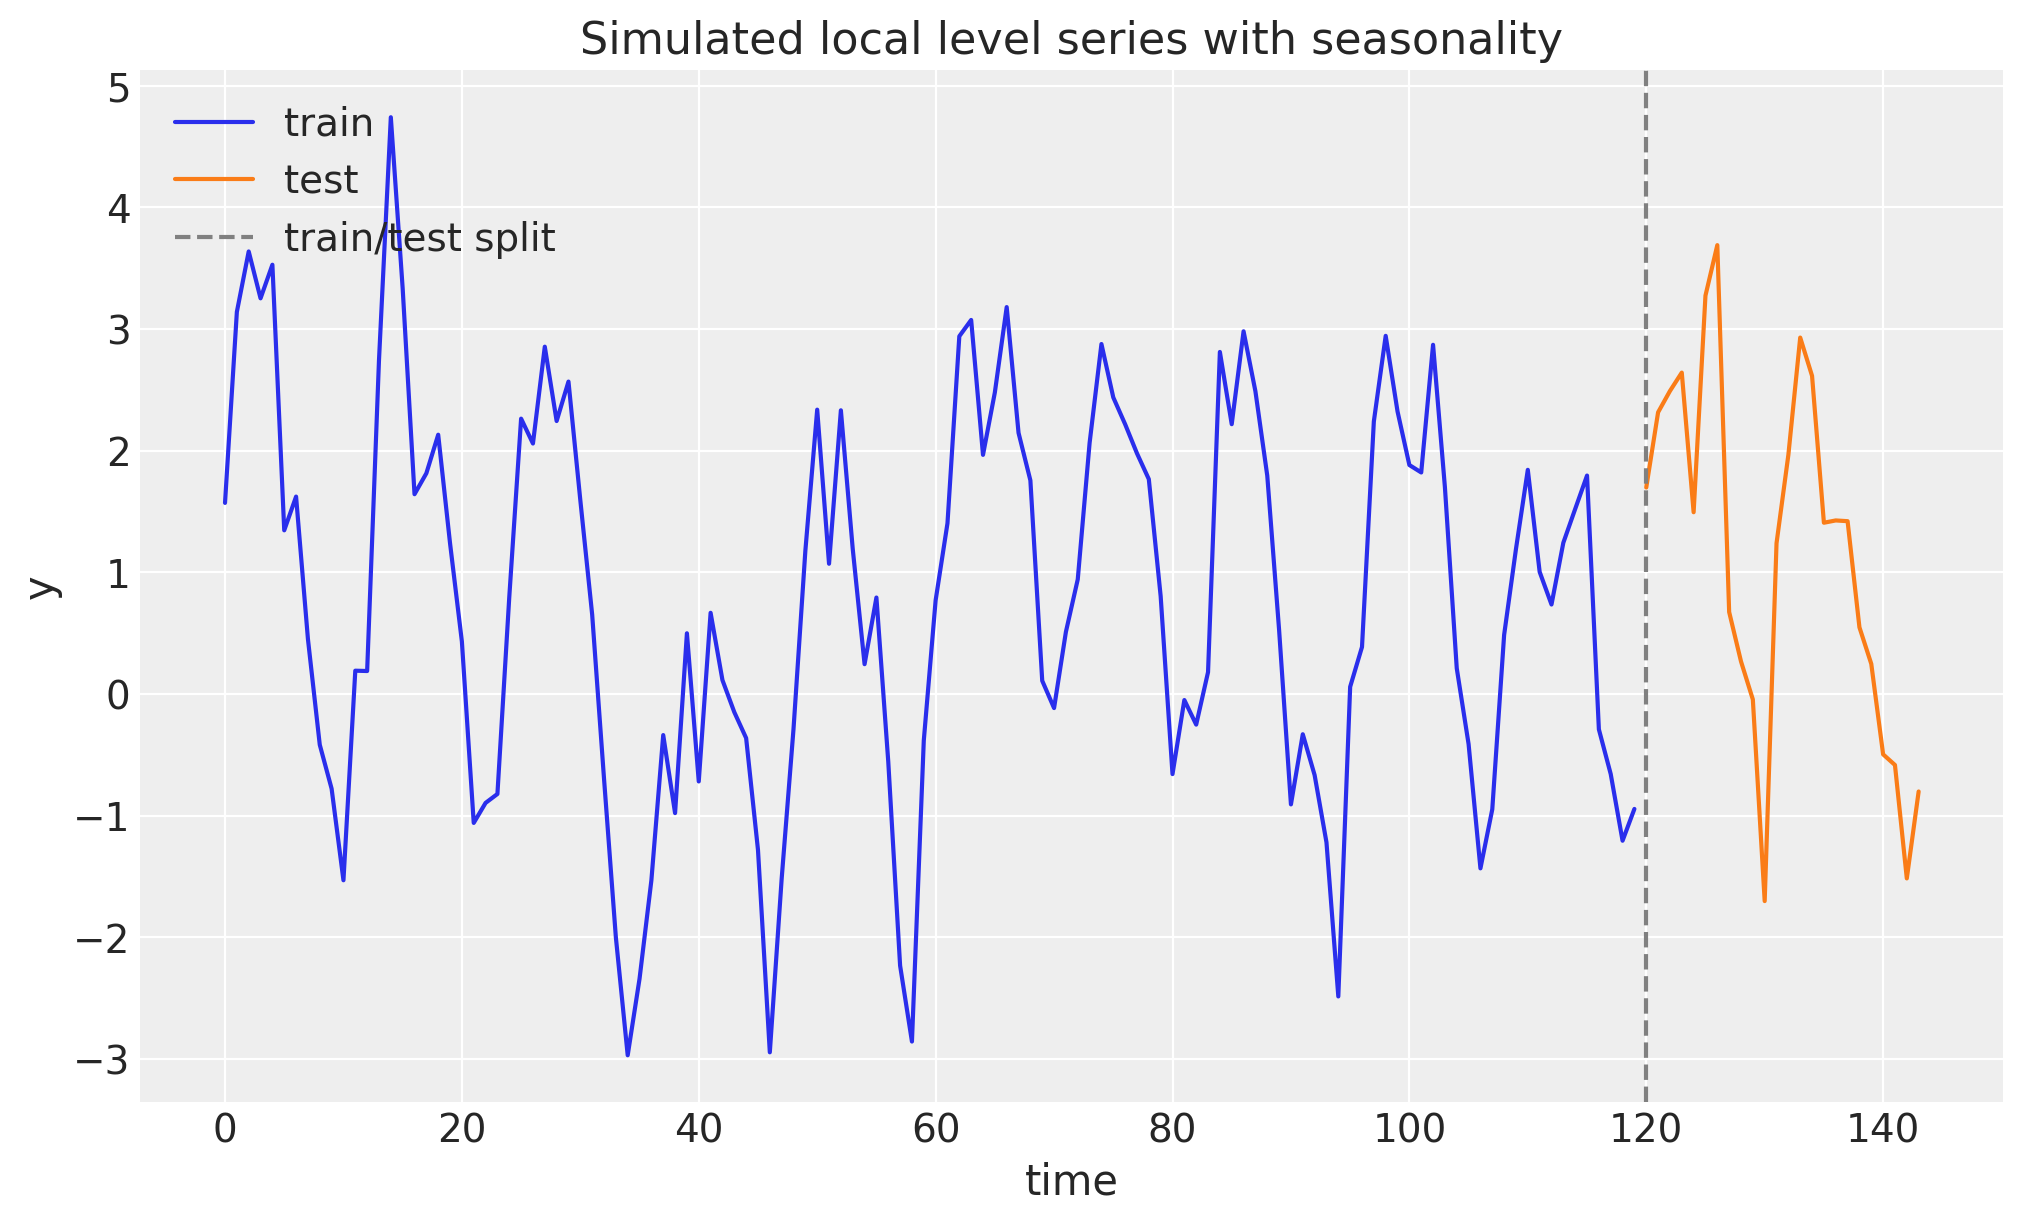

In [20]:
period, num_terms = 12.0, 2
beta_true = jnp.array([1.5, 0.5, -0.4, 0.3])
features_full = fourier_features(duration, period=period, num_terms=num_terms)  # (duration, 4)


def seasonal_level_dynamics(q: Array, r: Array, beta: Array) -> DynamicalModel:
    """Local level dynamics with a regression on the controls in the observation equation."""
    return dsx.LTI_discrete(
        A=jnp.eye(1),
        Q=jnp.eye(1) * q**2,
        H=jnp.eye(1),
        R=jnp.eye(1) * r**2,
        D=beta[None, :],
        initial_mean=jnp.zeros(1),
        initial_cov=jnp.eye(1) * 100.0,
    )


rng_key, rng_subkey = random.split(rng_key)
simulated_seasonal = dsx.simulate(
    seasonal_level_dynamics(jnp.asarray(q_true), jnp.asarray(r_true), beta_true),
    rng_key=rng_subkey,
    ctrl_times=jnp.asarray(time_grid),
    ctrl_values=features_full,
    predict_times=jnp.asarray(time_grid),
)
assert simulated_seasonal.observations is not None  # raw simulation
y_seasonal = simulated_seasonal.observations[0]  # (duration, 1)
train_seasonal, test_seasonal = y_seasonal[:t_obs], y_seasonal[t_obs:]
covariates_seasonal = jnp.concatenate([y_seasonal, features_full], axis=-1)  # (duration, 5)
covariates_seasonal_train = covariates_seasonal[:t_obs]

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], train_seasonal[:, 0], color="C0", label="train")
ax.plot(time_index[t_obs:], test_seasonal[:, 0], color="C1", label="test")
ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated local level series with seasonality", xlabel="time", ylabel="y");

The seasonal pattern is visible on top of the moving level.

### Model Specification

The model splits the covariate array into the observed window and the
controls, adds a $\text{Normal}(0, 1)$ prior on the four coefficients,
and conditions with the same smoother as before.

In [21]:
def seasonal_level_state_space(conditioner: StateSpaceHandler) -> ForecastModel:
    """Build the local level plus seasonal regression model conditioned by a dynestyx handler."""

    def model(covariates: Array, data: Array | None = None) -> None:
        h = Horizon.from_data(covariates, data)
        y = covariates[..., : h.t_obs, :1]  # the observed series is the first column
        controls = covariates[..., 1:]  # the Fourier features span the full horizon
        q = numpyro.sample("q", dist.HalfNormal(1.0))
        r = numpyro.sample("r", dist.HalfNormal(1.0))
        beta = numpyro.sample(
            "beta", dist.Normal(0.0, 1.0).expand([controls.shape[-1]]).to_event(1)
        )
        state_space_series(
            h,
            "f",
            y,
            seasonal_level_dynamics(q, r, beta),
            conditioner=conditioner,
            controls=controls,
        )

    return model


seasonal_level_smoothed = seasonal_level_state_space(
    Smoother(smoother_config=KFSmootherConfig(filter_source="cd_dynamax"))
)

### Model Fitting

Variational inference is the other standard path in the package, and it
works on the smoothed model without changes. `AutoNormal` puts a
mean-field Gaussian on the six unconstrained parameters and `Trace_ELBO`
includes the smoother’s factor.

Because the level is integrated out, the guide does not have to
approximate a $t_{\text{obs}}$-dimensional latent path, which is where
mean-field guides usually underestimate uncertainty. We draw the
posterior with
[`draw_posterior`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.draw_posterior.html)
and forecast as before.

SVI: 2.6 s, final loss 147.32
posterior mean of beta: [ 1.68  0.54 -0.38  0.23]
truth:                  [ 1.5  0.5 -0.4  0.3]

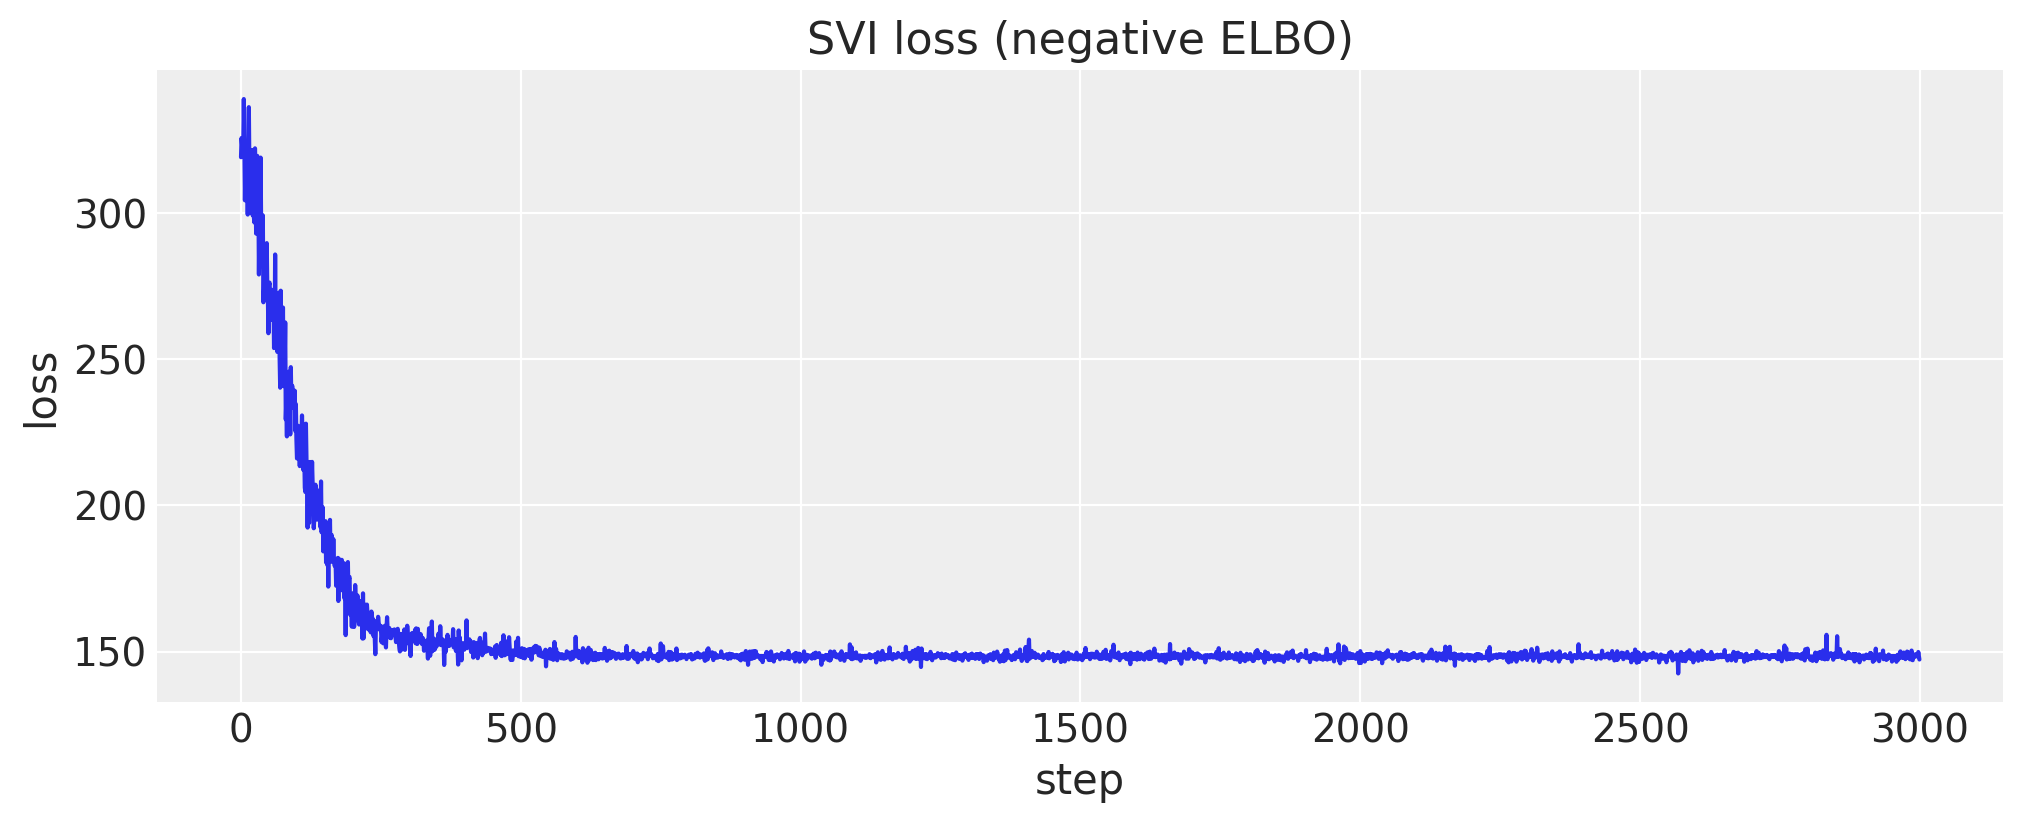

In [22]:
guide = AutoNormal(seasonal_level_smoothed)
svi = SVI(seasonal_level_smoothed, guide, Adam(step_size=0.01), Trace_ELBO())

rng_key, rng_subkey = random.split(rng_key)
start = time.perf_counter()
svi_result = svi.run(
    rng_subkey, 3_000, covariates_seasonal_train, train_seasonal, progress_bar=False
)
wall_svi = time.perf_counter() - start

rng_key, key_post, key_pred = random.split(rng_key, 3)
posterior_svi = draw_posterior(key_post, guide, svi_result.params, num_samples=2_000)
forecast_svi = forecast(
    key_pred, seasonal_level_smoothed, posterior_svi, train_seasonal, covariates_seasonal
)
print(f"SVI: {wall_svi:.1f} s, final loss {float(svi_result.losses[-1]):.2f}")
print(f"posterior mean of beta: {np.asarray(posterior_svi['beta']).mean(axis=0).round(2)}")
print(f"truth:                  {np.asarray(beta_true)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.asarray(svi_result.losses), color="C0")
ax.set(title="SVI loss (negative ELBO)", xlabel="step", ylabel="loss");

The loss flattens well before the $3{,}000$ steps, and the posterior
mean of `beta` is close to the truth.

### Forecast

We plot the SVI forecast with `az.plot_lm`.

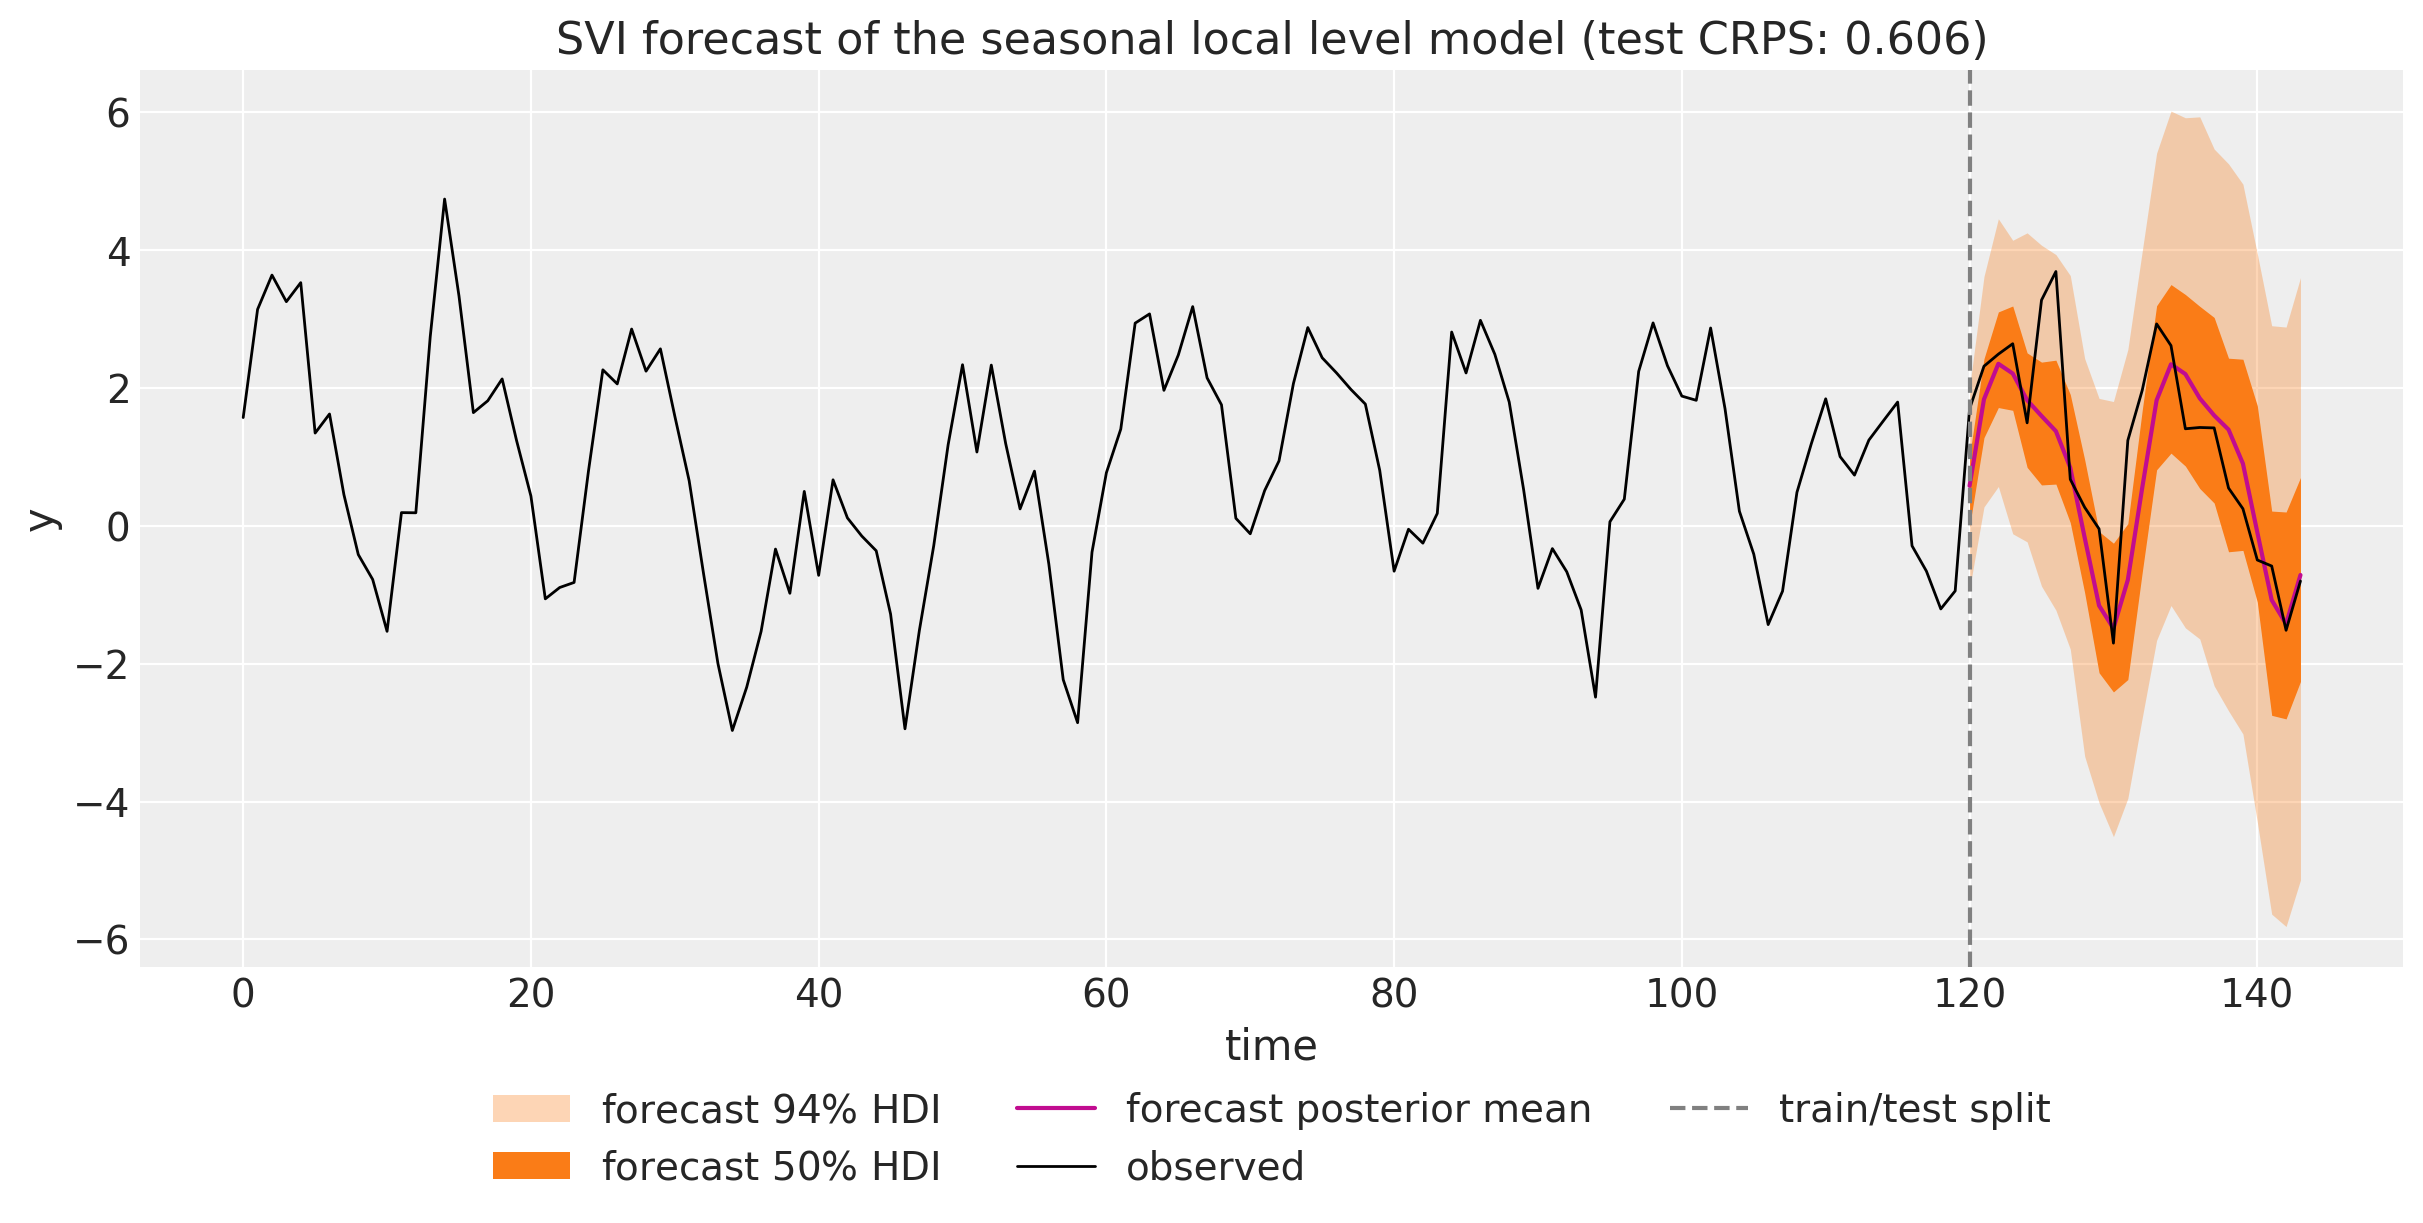

In [23]:
idata_forecast = predictions_to_datatree(
    forecast_svi, future_index.astype(float), ["y"], observed=test_seasonal
)
pc = az.plot_lm(
    idata_forecast,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C1"},
        "observed_scatter": False,
        "pe_line": {"color": "C3", "alpha": 1.0, "width": 1.5},
    },
    figure_kwargs={"figsize": (12, 6)},
)
bands = pc.viz["ci_band"]["t"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line = pc.viz["pe_line"]["t"].item()
pe_line.set_label("forecast posterior mean")
ax = pc.viz["figure"].item().axes[0]
(obs_line,) = ax.plot(
    time_index, np.asarray(y_seasonal[:, 0]), color="black", lw=1, label="observed"
)
split_line = ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
crps_svi = eval_crps(forecast_svi, test_seasonal)
ax.set(
    title=f"SVI forecast of the seasonal local level model (test CRPS: {crps_svi:.3f})",
    xlabel="time",
    ylabel="y",
);

The forecast follows the seasonal pattern into the test window, and the
bands widen slowly with the horizon.

### Expanding-Window Backtest

A single split scores one held-out window.
[`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html)
moves the train/test boundary forward, refits from scratch and forecasts
the next window, so every later part of the series is scored out of
sample once.

The loop delegates fitting and forecasting to two closures we write.
`forecast_fn` fits the model with NUTS on the fold’s training window and
passes the draws to `forecast`. `in_sample_fn` does the same and passes
them to `predict_in_sample`, so that with `eval_train=True` every fold
is also scored in sample.

The `dynestyx` model needs no adapter for any of this. It is a
`numpyro_forecast` model, and the closures are the same ones the other
examples use. We size the folds at $12$ steps (`test_window=12`,
`stride=12`) and seed the first training window with the first $72$
observations, which gives six folds.

In [24]:
def fit_fold(
    rng_key: Array, model: ForecastModel, train_data: Array, train_covariates: Array
) -> dict:
    """NUTS on one fold: 2 chains of 500 warmup and 500 draws, flattened."""
    mcmc, _ = fit_nuts(
        rng_key, model, train_data, train_covariates, num_chains=2, num_warmup=500, num_samples=500
    )
    return mcmc.get_samples()


def forecast_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with NUTS and forecast the test horizon."""
    key_fit, key_fc = random.split(rng_key)
    fold_posterior = fit_fold(key_fit, model, train_data, train_covariates)
    return forecast(
        key_fc, model, fold_posterior, train_data, full_covariates, batch_size=batch_size
    )


def in_sample_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with NUTS and score its in-sample fit."""
    key_fit, key_pred = random.split(rng_key)
    fold_posterior = fit_fold(key_fit, model, train_data, train_covariates)
    return predict_in_sample(
        key_pred, model, fold_posterior, train_covariates, batch_size=batch_size
    )


backtest_metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
start = time.perf_counter()
results = backtest(
    rng_subkey,
    lambda: seasonal_level_smoothed,
    y_seasonal,
    covariates_seasonal,
    forecast_fn=forecast_fn,
    in_sample_fn=in_sample_fn,
    metrics=backtest_metrics,
    test_window=12,
    stride=12,
    min_train_window=72,
    num_samples=1_000,  # 2 chains x 500 draws, what fit_fold returns
    eval_train=True,
    keep_predictions=True,
)
print(f"backtest: {len(results)} folds in {time.perf_counter() - start:.1f} s")
results_to_dataframe(results).round(3)

backtest: 6 folds in 79.7 s

Every fold reports its window, its out-of-sample scores and, with
`eval_train=True`, its in-sample scores. Overlaying the out-of-sample
forecast of every fold on the series gives the rolling-origin view. Each
band starts where its training window ends, and the dashed lines mark
the successive splits.

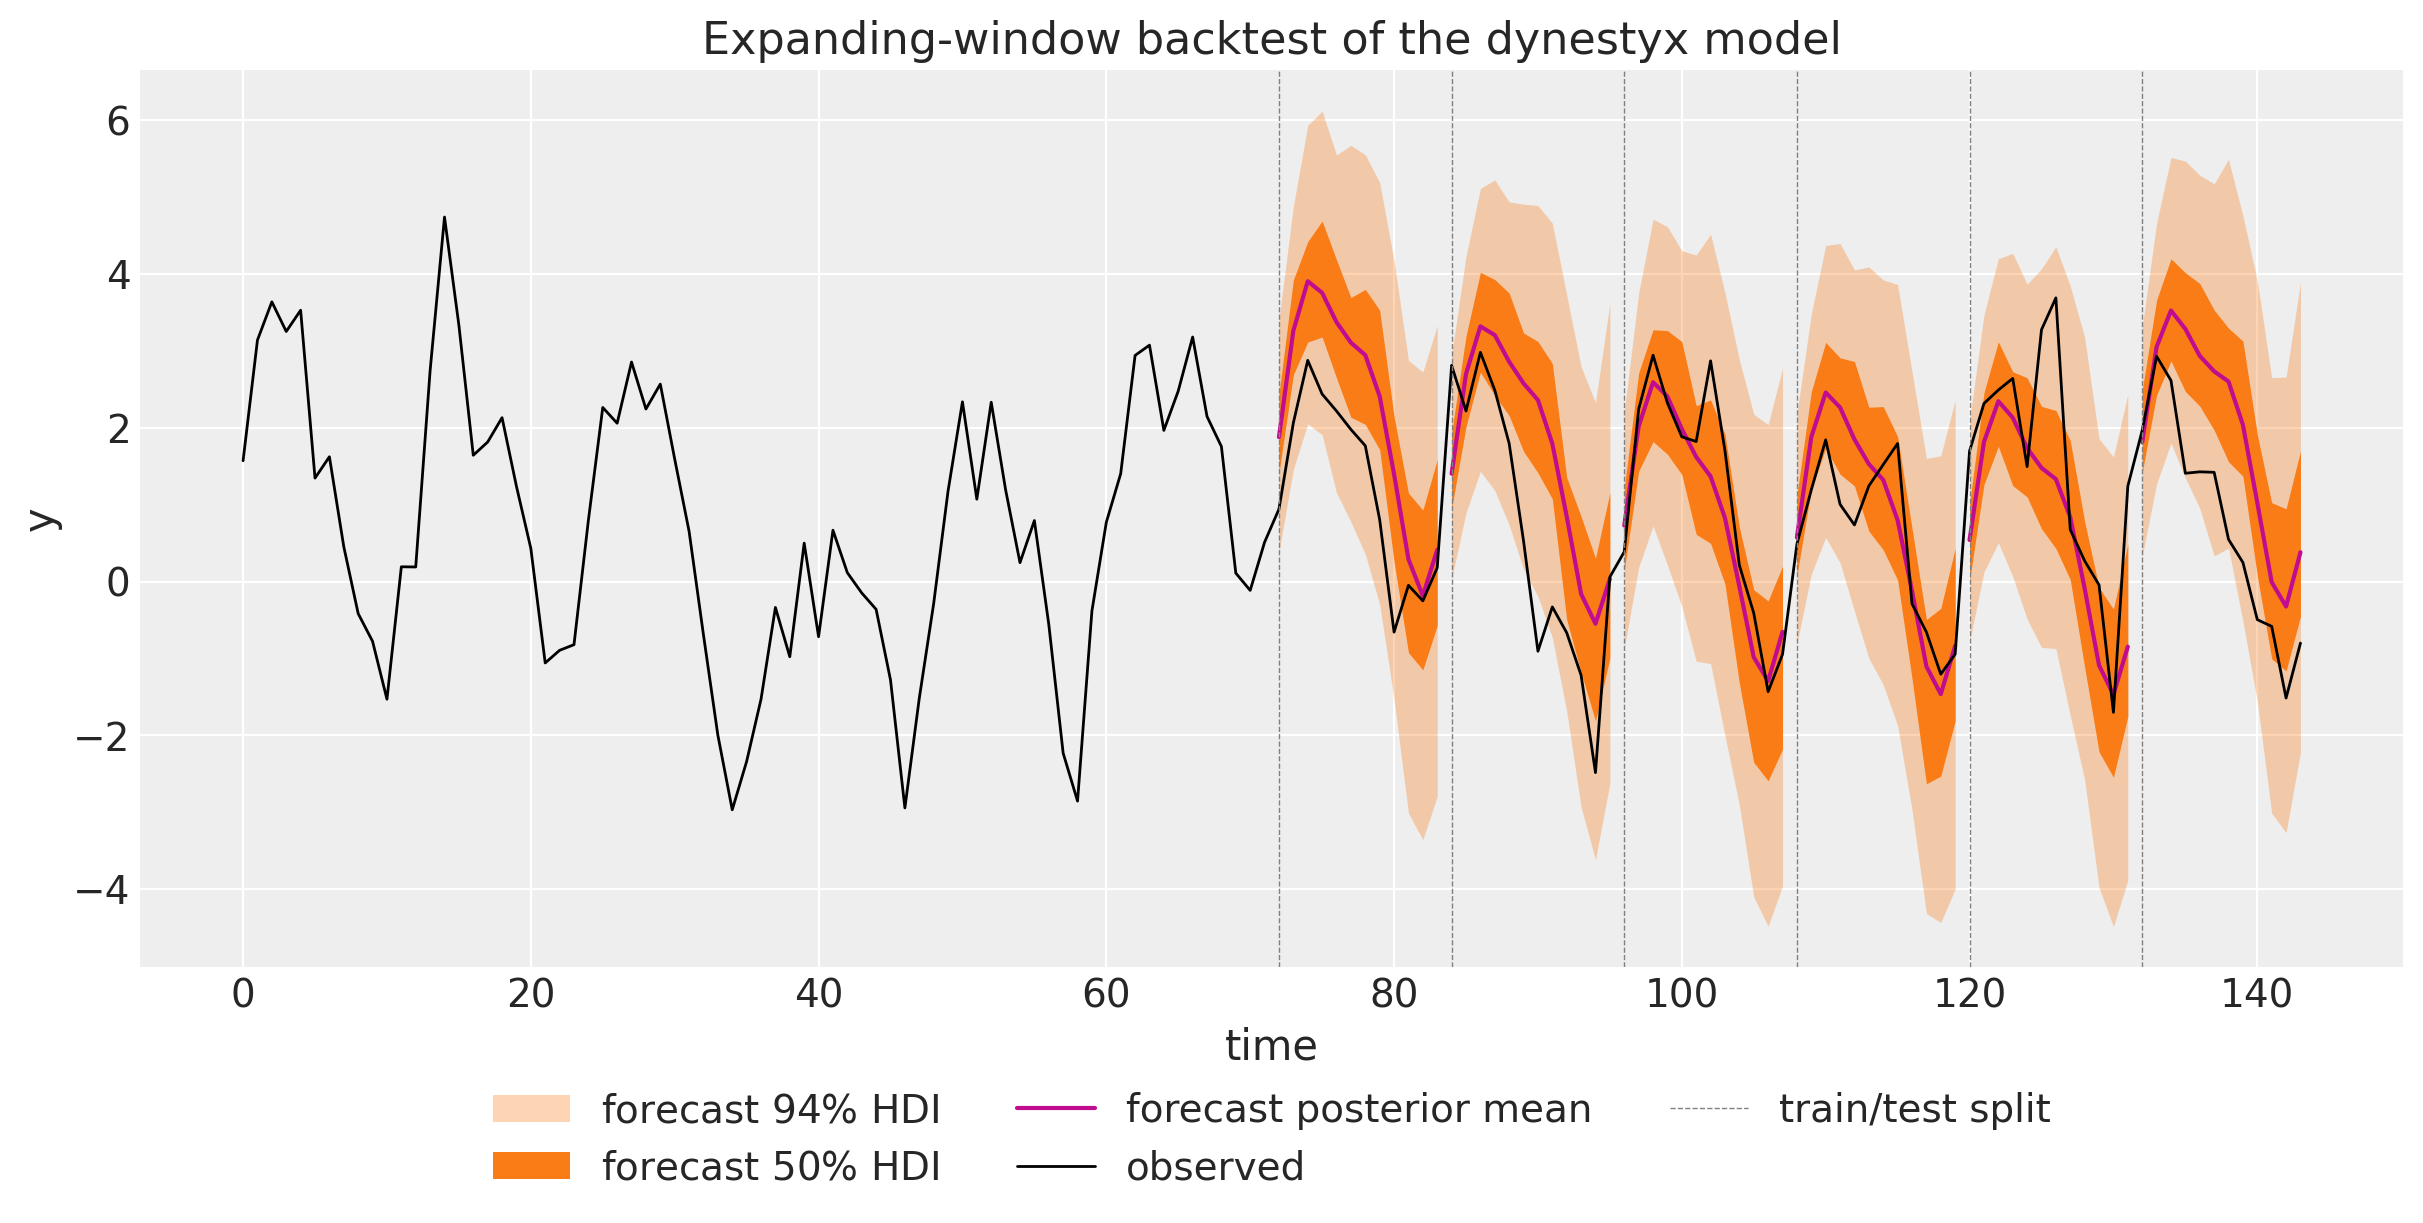

In [25]:
pc = None
for r in results:
    prediction = r.prediction
    if prediction is None:  # keep_predictions=True guarantees this never triggers
        continue
    fold_time = time_index[r.t1 : r.t2].astype(float)
    idata_fold = predictions_to_datatree(
        prediction, fold_time, ["y"], observed=y_seasonal[r.t1 : r.t2]
    )
    if pc is None:
        pc = az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C3", "alpha": 1.0, "width": 1.5},
            },
            figure_kwargs={"figsize": (12, 6)},
        )
        bands = pc.viz["ci_band"]["t"]
        band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
        pe_line = pc.viz["pe_line"]["t"].item()
    else:
        az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C3", "alpha": 1.0, "width": 1.5},
            },
        )

if pc is None:
    msg = "no folds were plotted"
    raise ValueError(msg)
ax = pc.viz["figure"].item().axes[0]
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line.set_label("forecast posterior mean")
(obs_line,) = ax.plot(
    time_index, np.asarray(y_seasonal[:, 0]), color="black", lw=1, label="observed"
)
split_lines = [
    ax.axvline(r.t1, color="gray", ls="--", lw=0.5, label="train/test split") for r in results
]
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line, split_lines[0]],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="Expanding-window backtest of the dynestyx model", xlabel="time", ylabel="y");

The bands track the series across all six folds. Finally, we look at the
per-fold scores.

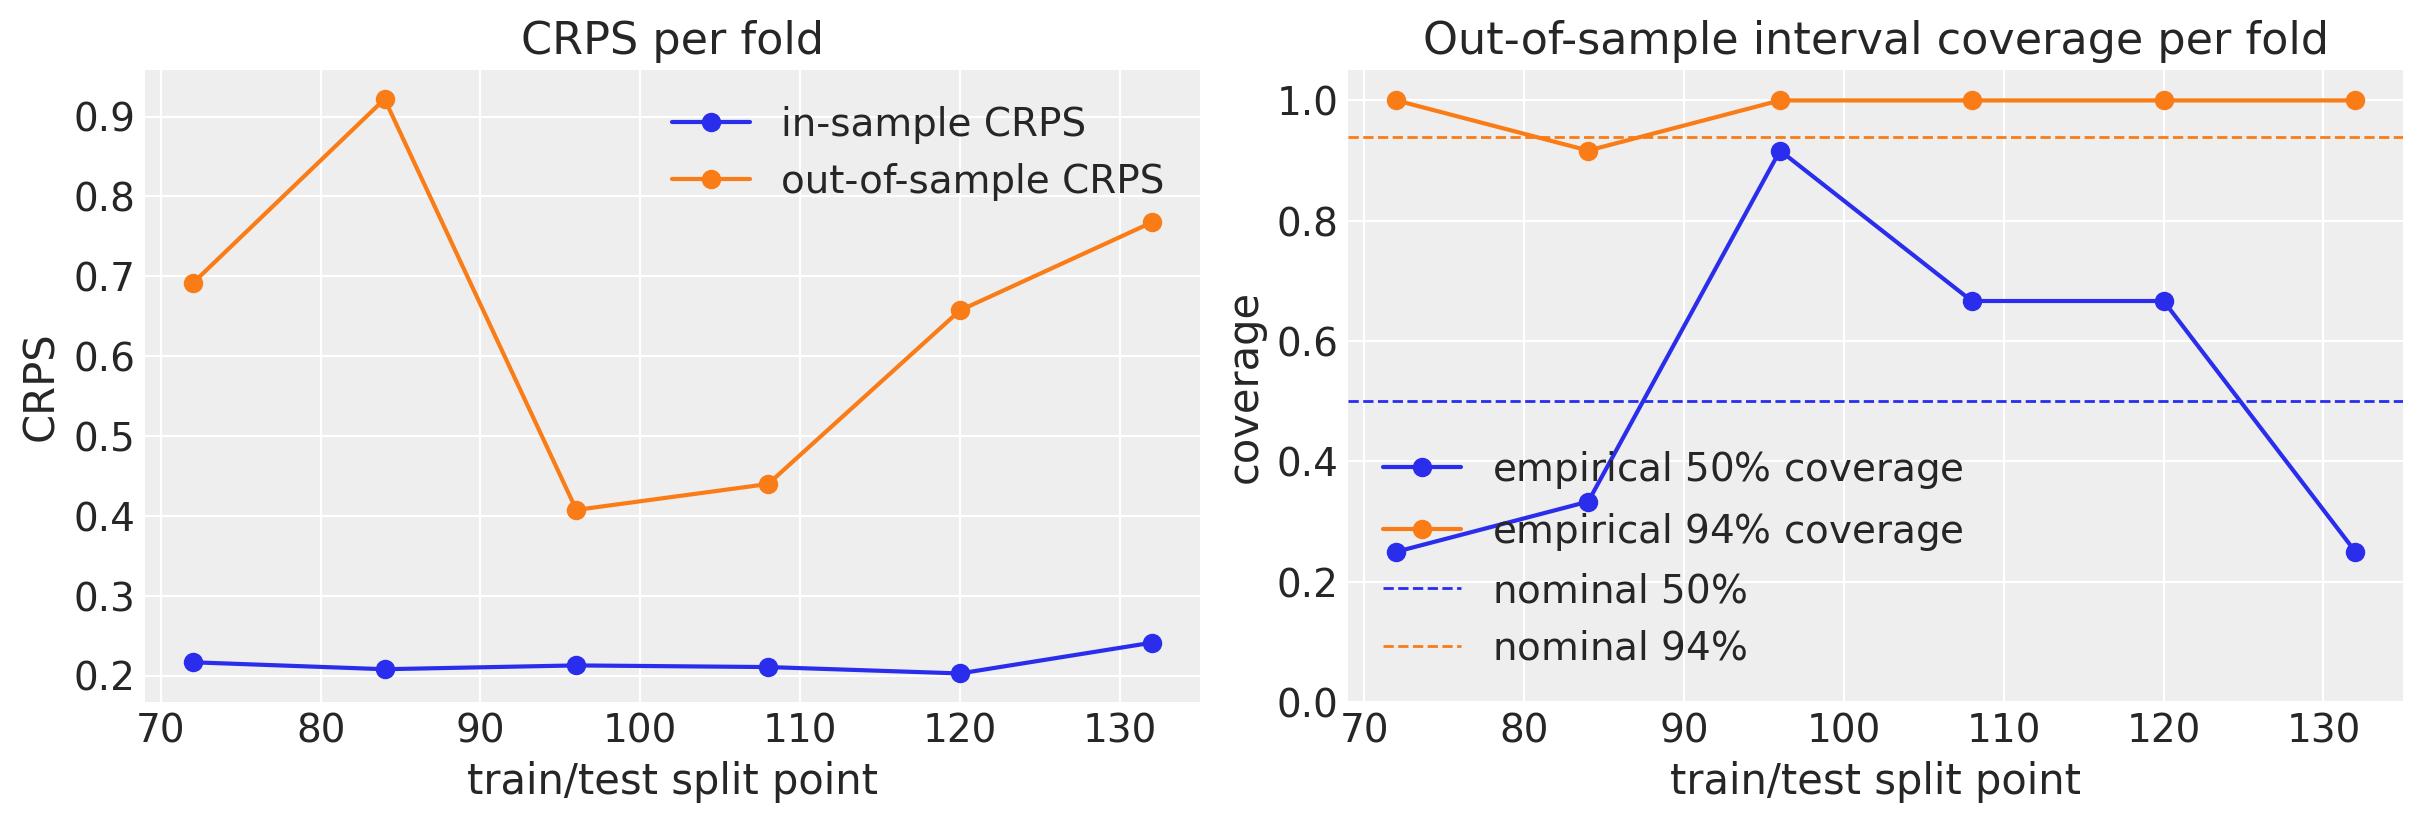

In [26]:
split_points = [r.t1 for r in results]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
axes[0].plot(
    split_points,
    [r.train_metrics["crps"] for r in results],
    "o-",
    color="C0",
    label="in-sample CRPS",
)
axes[0].plot(
    split_points,
    [r.metrics["crps"] for r in results],
    "o-",
    color="C1",
    label="out-of-sample CRPS",
)
axes[0].legend()
axes[0].set(xlabel="train/test split point", ylabel="CRPS", title="CRPS per fold")
axes[1].plot(
    split_points,
    [r.metrics["coverage_50"] for r in results],
    "o-",
    color="C0",
    label=r"empirical $50\%$ coverage",
)
axes[1].plot(
    split_points,
    [r.metrics["coverage_94"] for r in results],
    "o-",
    color="C1",
    label=r"empirical $94\%$ coverage",
)
axes[1].axhline(0.5, color="C0", ls="--", lw=1, label=r"nominal $50\%$")
axes[1].axhline(0.94, color="C1", ls="--", lw=1, label=r"nominal $94\%$")
axes[1].legend(loc="lower left")
axes[1].set(
    xlabel="train/test split point",
    ylabel="coverage",
    title="Out-of-sample interval coverage per fold",
    ylim=(0, 1.05),
);

The in-sample CRPS is stable across folds and well below the
out-of-sample CRPS, as expected for a smoothing predictive that has seen
the observations it scores.

The out-of-sample CRPS varies more from fold to fold, because each fold
scores only $12$ observations and the level of the series can drift away
from the forecast within a window.

The empirical coverage of the central $50\%$ interval moves around the
nominal level from fold to fold, and the $94\%$ interval covers all or
all but one of the $12$ observations in every fold. With $12$
observations per fold each observation moves the coverage by about
$0.08$, so this variation is expected.

## Conclusion

### Key Findings

- **One block, one argument.** A `dynestyx` model becomes a
  `numpyro_forecast` model through `state_space_series`, and the handler
  stack passed as its `conditioner` is the inference strategy. A
  `Smoother` (or `Filter`) integrates the latent path out, a
  `LatentPathBuilder` samples it explicitly, a `Discretizer` after
  either handles continuous-time dynamics, and switching between them is
  a change of one argument.
- **The drivers work without changes.** The block owns the likelihood
  and registers the horizon rollout as `"forecast"` and the in-sample
  predictive as `"obs"`. `forecast`, `predict_in_sample`, `to_datatree`,
  `backtest` (in and out of sample) and the metrics work on it under the
  same `jit` and `vmap` as for every other model.
- **The three strategies agree.** On the local level model the
  posteriors, the forecasts, the in-sample bands and the reconstructed
  level coincide across the direct model, the explicit path and the
  smoother.
- **The smoother is the efficient choice.** On linear-Gaussian models it
  is exact, and the sampler explores the parameters only. It needs a
  small fraction of the gradient evaluations of the direct model for a
  larger effective sample size, and the smoothing distribution gives the
  in-sample predictive without a second fit. The backward pass makes a
  full evaluation more expensive than a filter evaluation, but it does
  not enter the gradient of the marginal log likelihood, so the smoother
  and the filter cost the same per gradient here.

### Model Limitations

- A `Smoother` or a `LatentPathBuilder` predicts at or after the end of
  the window only (a `Filter` also predicts inside the window, from the
  filtering distribution), so the in-sample predictive comes from the
  conditioned distributions and not from a rollout, and it is a per-step
  marginal. A functional of the whole path would need backward
  simulation.
- A `Filter` conditioner has no in-sample predictive. Use a `Smoother`
  instead: it reports the same marginal log likelihood, so the two
  handlers share the parameter posterior. They do not share the
  distribution over the states. The filtering distribution uses the
  observations up to step $t$, the smoothing distribution uses the whole
  window, and the smoothed level is the better reconstruction of the
  true state.
- The observed window travels in the covariates, the time grids are
  NumPy constants for a `Filter` rollout and jax arrays for a
  `LatentPathBuilder`, and the rollout is anchored at the last observed
  step. The block handles all three. A rewrite that derives `times` from
  a covariate column would break the `Filter` rollout under `jit`.
- The `ssoe` family of the package (exponential smoothing in innovations
  form) has no stochastic latent to integrate out: with a single source
  of error its state is a deterministic function of the past
  observations, so its likelihood is exact given the parameters, and it
  has no `dynestyx` counterpart. Its members that are Markov in the
  observations (autoregressions) can be written with
  `DiracIdentityObservation` under a `LatentPathBuilder`, see the design
  document.

### Recommendations

1.  Use a `Smoother` with `KFSmootherConfig(filter_source="cd_dynamax")`
    on linear-Gaussian models, and switch to `filter_source="cuthbert"`
    when you need missing observations, time-varying parameters or a GPU
    on long series.
2.  Use a `LatentPathBuilder` when the path itself is the object of
    interest, the observation model is non-Gaussian, or the dynamics are
    discretized continuous-time.
3.  Put `LocScaleReparam` on the direct model in any comparison, as we
    did here.
4.  Create the `dynestyx` handlers once, outside the model, and pass the
    KF configurations explicitly: `Filter()` defaults to an ensemble
    Kalman filter and `Smoother()` to an extended Kalman smoother on the
    `cuthbert` backend, which are approximate or needlessly expensive on
    a linear-Gaussian model.

## Next Steps

1.  **Continuous-time dynamics.** A mean-reverting level on irregularly
    spaced observations, with a `Discretizer` after the smoother, is the
    case `dynestyx` supports and the index-based blocks of the package
    cannot express. The design document records the recipe and the
    caveats that keep it out of this notebook for now.
2.  **Nonlinear and non-Gaussian models.** The approximate filters and
    smoothers of `dynestyx` (ensemble, extended, unscented and particle)
    extend the block beyond the linear-Gaussian case. The particle
    filter gives an unbiased likelihood estimate and therefore
    pseudo-marginal inference; the ensemble, extended and unscented
    Kalman filters give biased Gaussian approximations.
3.  **Missing observations.** `NaN` values in the window are supported
    by the `cuthbert` backend for the Kalman and ensemble Kalman filters
    and smoothers, and by the builder’s `missing_observation_strategy`.
    The models of the package have no missing-data support.
4.  **A `contrib` module.** Once the maintainers of both libraries have
    reviewed the composition, the block moves to
    `numpyro_forecast.contrib.dynestyx` and this notebook imports it.

## References

- Waxman, D., Batenkov, D., Feser, J., Zane, A., Bingham, E., Marzouk,
  Y., & Levine, M. E. (2026). [*Dynestyx: A Probabilistic Programming
  Library for Dynamical Systems*](https://arxiv.org/abs/2606.16985).
- [`dynestyx`
  documentation](https://basisresearch.github.io/dynestyx/stable/), in
  particular the tutorials on [filtering and the marginal
  likelihood](https://basisresearch.github.io/dynestyx/stable/tutorials/gentle_intro/03_filtering_mll/)
  and on [discrete-time
  smoothing](https://basisresearch.github.io/dynestyx/stable/tutorials/gentle_intro/09_discrete_smoothing/).
- Durbin, J., & Koopman, S. J. (2012). *Time Series Analysis by State
  Space Methods*, 2nd edition. Oxford University Press.
- Särkkä, S., & Svensson, L. (2023). [*Bayesian Filtering and
  Smoothing*](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf),
  2nd edition. Cambridge University Press.
- [Design document: integrating `numpyro_forecast` with
  `dynestyx`](https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/dev/dynestyx_integration_design.md),
  the internal document this notebook implements.